In [125]:
import pandas as pd
import numpy as np

df = pd.read_csv("Palo Alto Networks.csv")

print("Dataset shape:", df.shape)

Dataset shape: (1470, 31)


In [126]:
import pandas as pd
import numpy as np

df = pd.read_csv('Palo Alto Networks.csv')

print(df.shape)
print(df.info())

df.head()

(1470, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfacti

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [127]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [128]:
df.duplicated().sum()

np.int64(0)

In [129]:
import pandas as pd
import numpy as np

df = pd.read_csv('Palo Alto Networks.csv')

print(df.shape)
df.head()

(1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [130]:
# ==============================
# STEP 2: FEATURE ENGINEERING
# ==============================

import numpy as np
import numpy as np




# Avoid division by zero
df['YearsAtCompany_Safe'] = df['YearsAtCompany'].replace(0, 1)
df['TotalWorkingYears_Safe'] = df['TotalWorkingYears'].replace(0, 1)

# 1. Promotion Gap Ratio
df['PromotionGapRatio'] = (
    df['YearsSinceLastPromotion'] / df['YearsAtCompany_Safe']
)

# 2. Role Stagnation Index
df['RoleStagnationIndex'] = (
    df['YearsInCurrentRole'] / df['YearsAtCompany_Safe']
)

# 3. Training Intensity Score
df['TrainingIntensityScore'] = (
    df['TrainingTimesLastYear'] / df['YearsAtCompany_Safe']
)

# 4. Manager Stability Indicator
df['ManagerStabilityIndicator'] = (
    df['YearsWithCurrManager'] / df['YearsAtCompany_Safe']
)

# 5. Career Velocity Score
df['CareerVelocityScore'] = (
    df['JobLevel'] / df['TotalWorkingYears_Safe']
)

# 6. Salary Growth Proxy
df['SalaryGrowthProxy'] = (
    df['PercentSalaryHike'] * df['JobLevel']
)

# 7. Career Stage
def career_stage(years):
    if years < 3:
        return 'Early Career'
    elif years < 7:
        return 'Growth Stage'
    elif years < 15:
        return 'Mid Career'
    else:
        return 'Senior Career'

df['CareerStage'] = df['YearsAtCompany'].apply(career_stage)

# Display the newly created features
new_features = [
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'CareerVelocityScore',
    'SalaryGrowthProxy',
    'CareerStage'
]

print(df[new_features].head())

   PromotionGapRatio  RoleStagnationIndex  TrainingIntensityScore  \
0              0.000             0.666667                   0.000   
1              0.100             0.700000                   0.300   
2              0.000             0.000000                   3.000   
3              0.375             0.875000                   0.375   
4              1.000             1.000000                   1.500   

   ManagerStabilityIndicator  CareerVelocityScore  SalaryGrowthProxy  \
0                   0.833333             0.250000                 22   
1                   0.700000             0.200000                 46   
2                   0.000000             0.142857                 15   
3                   0.000000             0.125000                 11   
4                   1.000000             0.166667                 12   

    CareerStage  
0  Growth Stage  
1    Mid Career  
2  Early Career  
3    Mid Career  
4  Early Career  


In [131]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'YearsAtCompany_Safe', 'TotalWorkingYears_Safe', 'PromotionGapRatio', 'RoleStagnationIndex', 'TrainingIntensityScore', 'ManagerStabilityIndicator', 'CareerVelocityScore', 'SalaryGrowthProxy', 'CareerStage']


In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# Better looking plots
plt.style.use('default')
sns.set_theme(style='whitegrid')

# Make plots larger
plt.rcParams['figure.figsize'] = (8,5)

In [133]:
import pandas as pd
import numpy as np

# Load your dataset again
df = pd.read_csv('Palo Alto Networks.csv')

# Verify it loaded
print(df.shape)
df.head()

(1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


Attrition
0    1233
1     237
Name: count, dtype: int64


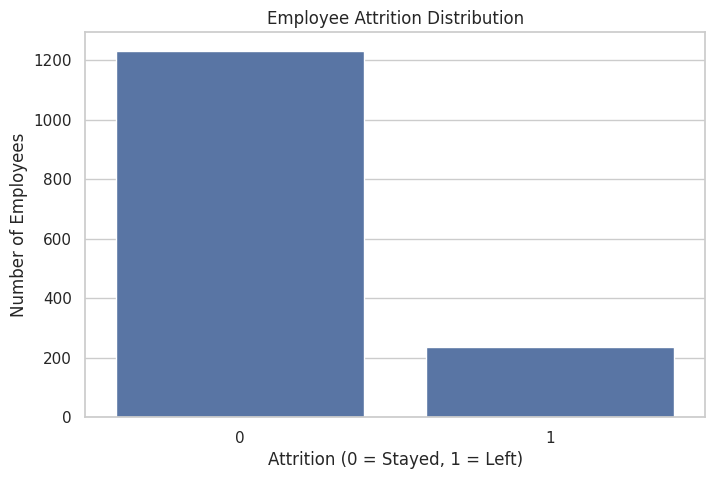

In [134]:
print(df['Attrition'].value_counts())

sns.countplot(data=df, x='Attrition')

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Employees')

plt.show()

In [135]:
import pandas as pd
import numpy as np

# Load your dataset again
df = pd.read_csv('Palo Alto Networks.csv')

# Verify it loaded
print(df.shape)
df.head()

(1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [136]:
attrition_rate = df['Attrition'].mean() * 100
print(f'Attrition Rate: {attrition_rate:.2f}%')

Attrition Rate: 16.12%


In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (8,5)

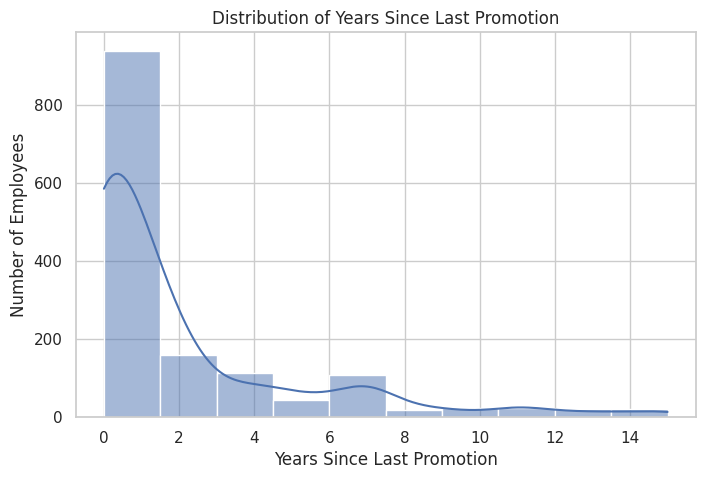

In [138]:
sns.histplot(df['YearsSinceLastPromotion'], bins=10, kde=True)

plt.title('Distribution of Years Since Last Promotion')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Number of Employees')

plt.show()

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (8,5)

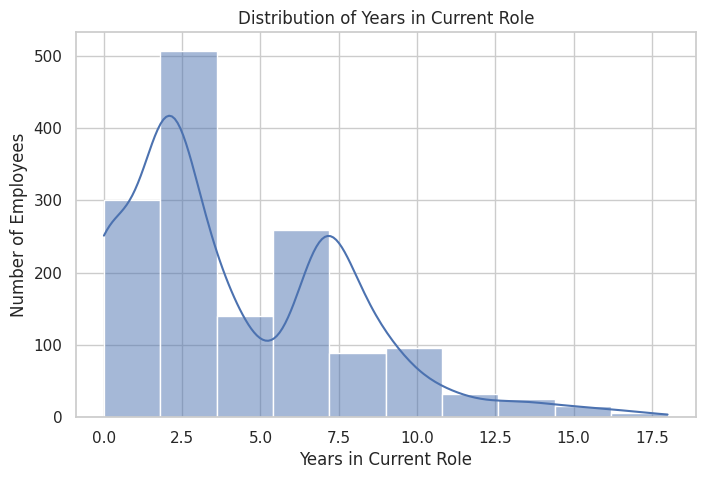

In [140]:
sns.histplot(df['YearsInCurrentRole'], bins=10, kde=True)

plt.title('Distribution of Years in Current Role')
plt.xlabel('Years in Current Role')
plt.ylabel('Number of Employees')

plt.show()

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (8,5)

In [142]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [157]:
# Restore dataframe and all engineered features

import pandas as pd
import numpy as np

df = pd.read_csv("Palo Alto Networks.csv")

# Safe denominators
df['YearsAtCompany_Safe'] = df['YearsAtCompany'].replace(0, 1)
df['TotalWorkingYears_Safe'] = df['TotalWorkingYears'].replace(0, 1)

# Career progression features
df['PromotionGapRatio'] = (
    df['YearsSinceLastPromotion'] / df['YearsAtCompany_Safe']
)

df['RoleStagnationIndex'] = (
    df['YearsInCurrentRole'] / df['YearsAtCompany_Safe']
)

df['TrainingIntensityScore'] = (
    df['TrainingTimesLastYear'] / df['YearsAtCompany_Safe']
)

df['ManagerStabilityIndicator'] = (
    df['YearsWithCurrManager'] / df['YearsAtCompany_Safe']
)

df['CareerVelocityScore'] = (
    df['JobLevel'] / df['TotalWorkingYears_Safe']
)

df['SalaryGrowthProxy'] = (
    df['PercentSalaryHike'] * df['JobLevel']
)

# Career stage
def career_stage(years):
    if years < 3:
        return 'Early Career'
    elif years < 7:
        return 'Growth Stage'
    elif years < 15:
        return 'Mid Career'
    else:
        return 'Senior Career'

df['CareerStage'] = df['YearsAtCompany'].apply(career_stage)

print("Dataframe restored successfully.")
print("Shape:", df.shape)

print("\nEngineered columns:")
print([
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'CareerVelocityScore',
    'SalaryGrowthProxy',
    'CareerStage'
])

display(df.head())

Dataframe restored successfully.
Shape: (1470, 40)

Engineered columns:
['PromotionGapRatio', 'RoleStagnationIndex', 'TrainingIntensityScore', 'ManagerStabilityIndicator', 'CareerVelocityScore', 'SalaryGrowthProxy', 'CareerStage']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,YearsWithCurrManager,YearsAtCompany_Safe,TotalWorkingYears_Safe,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,SalaryGrowthProxy,CareerStage
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,5,6,8,0.000,0.666667,0.000,0.833333,0.250000,22,Growth Stage
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,7,10,10,0.100,0.700000,0.300,0.700000,0.200000,46,Mid Career
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,1,7,0.000,0.000000,3.000,0.000000,0.142857,15,Early Career
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,0,8,8,0.375,0.875000,0.375,0.000000,0.125000,11,Mid Career
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,2,2,6,1.000,1.000000,1.500,1.000000,0.166667,12,Early Career


In [158]:
print('PromotionGapRatio' in df.columns)
print('RoleStagnationIndex' in df.columns)
print('CareerCluster' in df.columns)

True
True
False


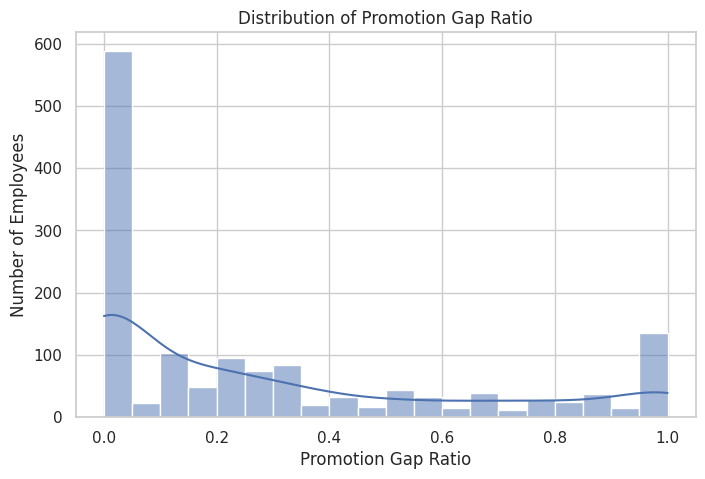

In [159]:
sns.histplot(df['PromotionGapRatio'], bins=20, kde=True)

plt.title('Distribution of Promotion Gap Ratio')
plt.xlabel('Promotion Gap Ratio')
plt.ylabel('Number of Employees')

plt.show()

Department
Sales                     0.306611
Research & Development    0.283291
Human Resources           0.280148
Name: PromotionGapRatio, dtype: float64


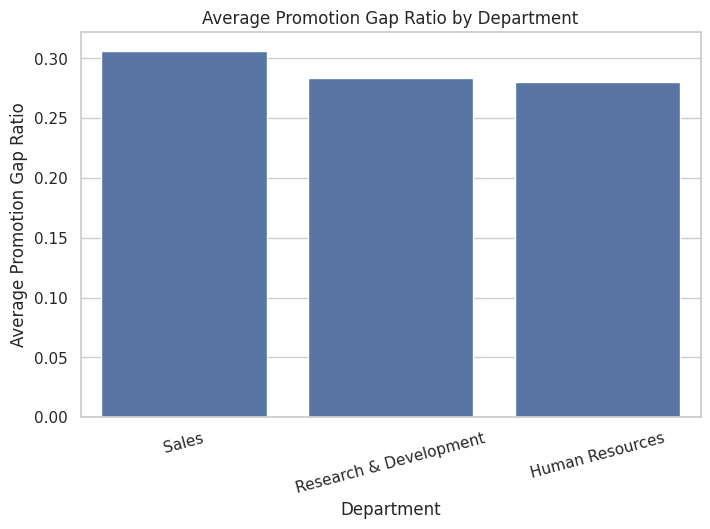

In [160]:
dept_promotion = (
    df.groupby('Department')['PromotionGapRatio']
      .mean()
      .sort_values(ascending=False)
)

print(dept_promotion)

sns.barplot(
    x=dept_promotion.index,
    y=dept_promotion.values
)

plt.title('Average Promotion Gap Ratio by Department')
plt.xlabel('Department')
plt.ylabel('Average Promotion Gap Ratio')

plt.xticks(rotation=15)
plt.show()

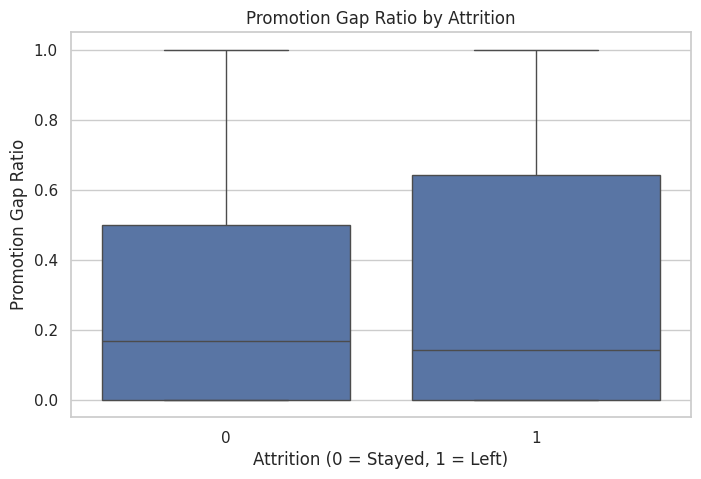

In [161]:
sns.boxplot(
    data=df,
    x='Attrition',
    y='PromotionGapRatio'
)

plt.title('Promotion Gap Ratio by Attrition')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Promotion Gap Ratio')

plt.show()

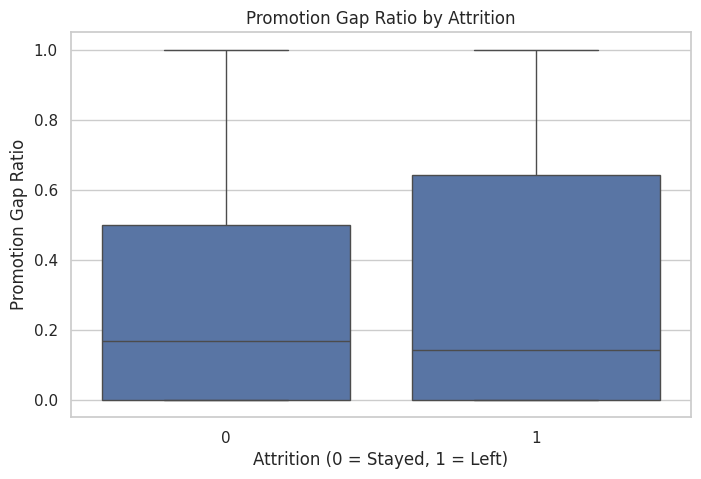

In [162]:
sns.boxplot(
    data=df,
    x='Attrition',
    y='PromotionGapRatio'
)

plt.title('Promotion Gap Ratio by Attrition')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Promotion Gap Ratio')

plt.show()

JobRole
Sales Executive              0.631967
Manufacturing Director       0.624808
Research Director            0.585805
Human Resources              0.581675
Research Scientist           0.573058
Healthcare Representative    0.566765
Laboratory Technician        0.546727
Sales Representative         0.514318
Manager                      0.493957
Name: RoleStagnationIndex, dtype: float64


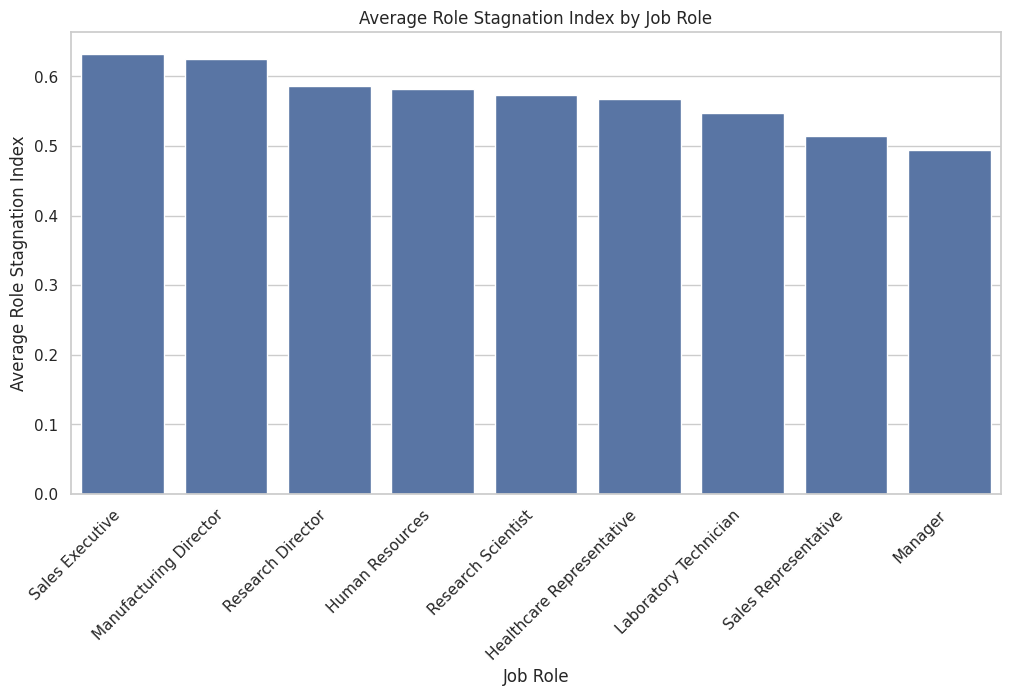

In [163]:
role_stagnation = (
    df.groupby('JobRole')['RoleStagnationIndex']
      .mean()
      .sort_values(ascending=False)
)

print(role_stagnation)

plt.figure(figsize=(12,6))
sns.barplot(
    x=role_stagnation.index,
    y=role_stagnation.values
)

plt.title('Average Role Stagnation Index by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Average Role Stagnation Index')
plt.xticks(rotation=45, ha='right')

plt.show()

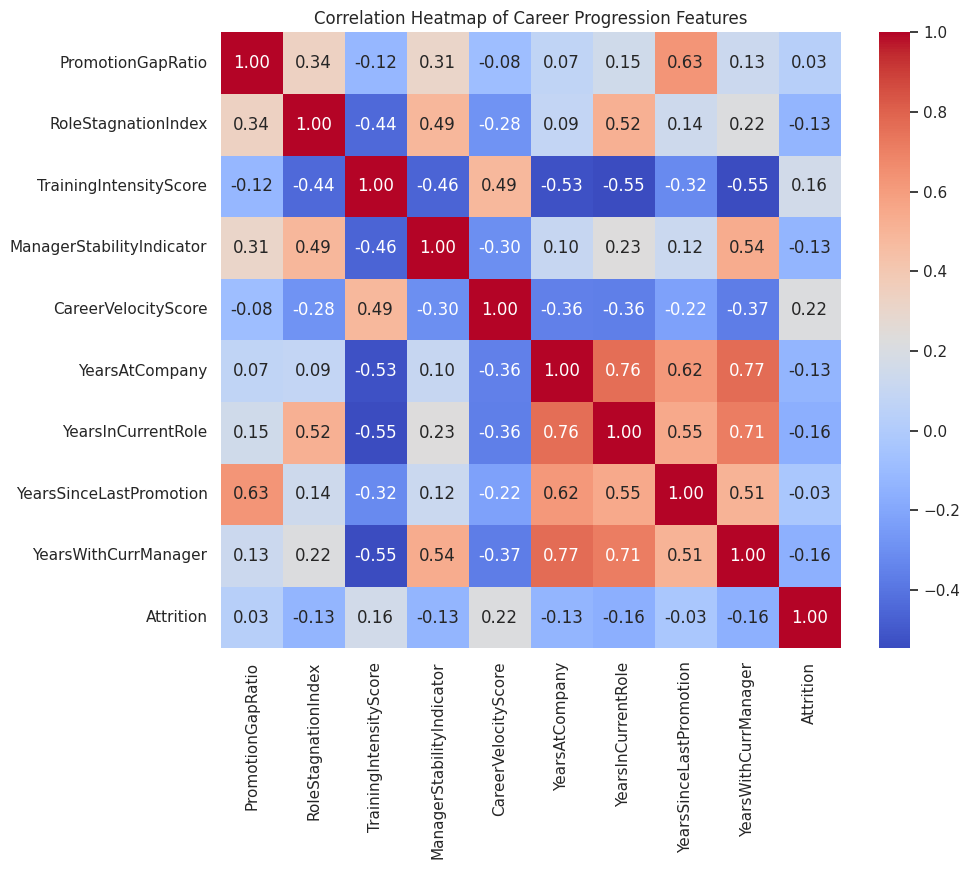

In [164]:
career_features = [
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'CareerVelocityScore',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager',
    'Attrition'
]

corr = df[career_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Career Progression Features')
plt.show()

In [165]:
# ==========================================
# STEP 4: PREPARE DATA FOR CLUSTERING
# ==========================================

import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("Palo Alto Networks.csv")

# Avoid division by zero
df['YearsAtCompany_Safe'] = df['YearsAtCompany'].replace(0, 1)
df['TotalWorkingYears_Safe'] = df['TotalWorkingYears'].replace(0, 1)

# Feature engineering
df['PromotionGapRatio'] = (
    df['YearsSinceLastPromotion'] / df['YearsAtCompany_Safe']
)

df['RoleStagnationIndex'] = (
    df['YearsInCurrentRole'] / df['YearsAtCompany_Safe']
)

df['TrainingIntensityScore'] = (
    df['TrainingTimesLastYear'] / df['YearsAtCompany_Safe']
)

df['ManagerStabilityIndicator'] = (
    df['YearsWithCurrManager'] / df['YearsAtCompany_Safe']
)

df['CareerVelocityScore'] = (
    df['JobLevel'] / df['TotalWorkingYears_Safe']
)

df['SalaryGrowthProxy'] = (
    df['PercentSalaryHike'] * df['JobLevel']
)

# Career Stage
def career_stage(years):
    if years < 3:
        return 'Early Career'
    elif years < 7:
        return 'Growth Stage'
    elif years < 15:
        return 'Mid Career'
    else:
        return 'Senior Career'

df['CareerStage'] = df['YearsAtCompany'].apply(career_stage)

print("Dataset loaded and feature engineering completed.")
print("Dataset shape:", df.shape)

Dataset loaded and feature engineering completed.
Dataset shape: (1470, 40)


In [167]:
# ==========================================
# STEP 4.1: SELECT FEATURES FOR K-MEANS
# ==========================================

career_features = [
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'CareerVelocityScore',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

X_cluster = df[career_features].copy()

print("Shape of clustering dataset:", X_cluster.shape)

X_cluster.head()

Shape of clustering dataset: (1470, 9)


,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.000,0.666667,0.000,0.833333,0.250000,6,4,0,5
1,0.100,0.700000,0.300,0.700000,0.200000,10,7,1,7
2,0.000,0.000000,3.000,0.000000,0.142857,0,0,0,0
3,0.375,0.875000,0.375,0.000000,0.125000,8,7,3,0
4,1.000,1.000000,1.500,1.000000,0.166667,2,2,2,2


In [166]:
# ==========================================
# STEP 4.2: CHECK MISSING VALUES & STATISTICS
# ==========================================

# Check for missing values
print("Missing values:")
print(X_cluster.isnull().sum())

# Check basic statistics
print("\nBasic statistics:")
display(X_cluster.describe())

Missing values:
PromotionGapRatio            0
RoleStagnationIndex          0
TrainingIntensityScore       0
ManagerStabilityIndicator    0
CareerVelocityScore          0
YearsAtCompany               0
YearsInCurrentRole           0
YearsSinceLastPromotion      0
YearsWithCurrManager         0
dtype: int64

Basic statistics:


,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.290232,0.578220,0.884039,0.558626,0.258806,7.008163,4.229252,2.187755,4.123129
std,0.340521,0.331966,1.079432,0.334732,0.213306,6.126525,3.623137,3.222430,3.568136
min,0.000000,0.000000,0.000000,0.000000,0.050000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.352500,0.250000,0.333333,0.142857,3.000000,2.000000,0.000000,2.000000
50%,0.166667,0.666667,0.500000,0.666667,0.200000,5.000000,3.000000,1.000000,3.000000
75%,0.500000,0.833333,1.000000,0.800000,0.285714,9.000000,7.000000,3.000000,7.000000
max,1.000000,1.000000,6.000000,1.000000,1.000000,40.000000,18.000000,15.000000,17.000000


In [168]:
# ==========================================
# STEP 4.3: CHECK FOR INFINITE VALUES
# ==========================================

import numpy as np

print("Infinite values:")
print(np.isinf(X_cluster).sum())

Infinite values:
PromotionGapRatio            0
RoleStagnationIndex          0
TrainingIntensityScore       0
ManagerStabilityIndicator    0
CareerVelocityScore          0
YearsAtCompany               0
YearsInCurrentRole           0
YearsSinceLastPromotion      0
YearsWithCurrManager         0
dtype: int64


In [169]:
# ==========================================
# STEP 4.4: OUTLIER DETECTION
# ==========================================

Q1 = X_cluster.quantile(0.25)
Q3 = X_cluster.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    ((X_cluster < lower_bound) | (X_cluster > upper_bound))
    .sum()
)

print("Number of potential outliers in each feature:")
print(outlier_counts)

Number of potential outliers in each feature:
PromotionGapRatio              0
RoleStagnationIndex            0
TrainingIntensityScore       133
ManagerStabilityIndicator      0
CareerVelocityScore           92
YearsAtCompany               104
YearsInCurrentRole            21
YearsSinceLastPromotion      107
YearsWithCurrManager          14
dtype: int64


In [170]:
# ==========================================
# STEP 4.5: FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print("Scaled data shape:", X_scaled.shape)

print("\nFirst 5 rows of scaled data:")
print(X_scaled[:5])

Scaled data shape: (1470, 9)

First 5 rows of scaled data:
[[-0.85260662  0.26652383 -0.81926405  0.82095878 -0.04129875 -0.16461311
  -0.0632959  -0.67914568  0.24583399]
 [-0.558839    0.36696993 -0.5412456   0.42249482 -0.27578406  0.48850773
   0.76499762 -0.36871529  0.80654148]
 [-0.85260662 -1.74239815  1.96092036 -1.66944099 -0.54376728 -1.14429437
  -1.16768726 -0.67914568 -1.15593471]
 [ 0.24902194  0.89431195 -0.47174099 -1.66944099 -0.62751204  0.16194731
   0.76499762  0.25214551 -1.15593471]
 [ 2.08506952  1.27098483  0.57082816  1.31903874 -0.43210761 -0.81773395
  -0.61549158 -0.05828489 -0.59522723]]


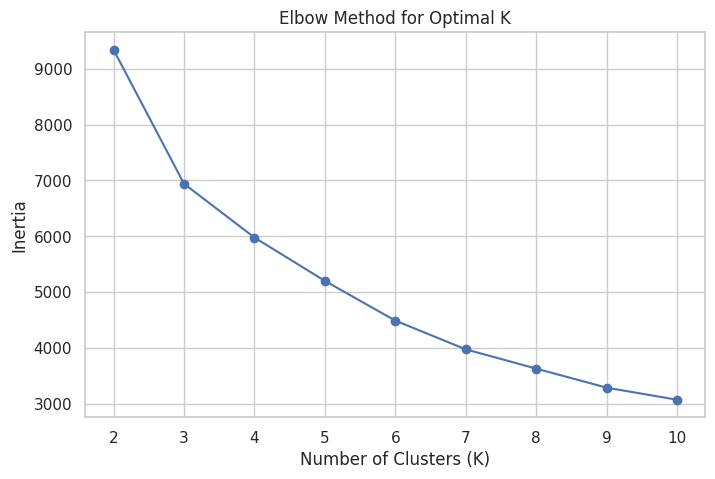

In [171]:
# ==========================================
# STEP 5.1: ELBOW METHOD
# ==========================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.xticks(K_range)
plt.show()

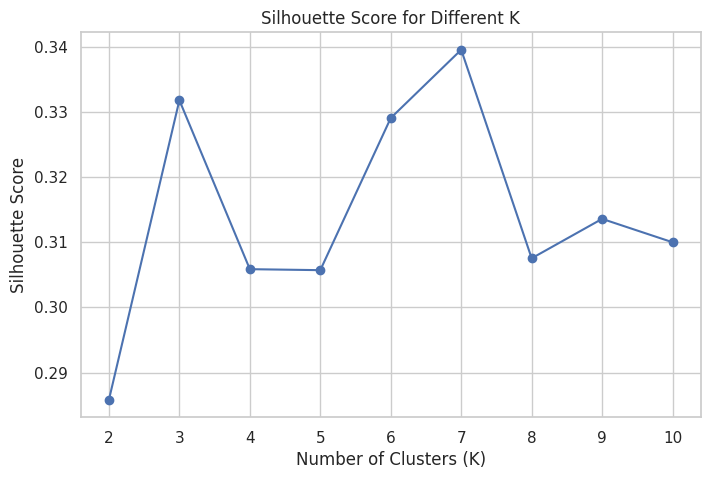

In [172]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(K_range, silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K')
plt.xticks(K_range)

plt.show()

Step 6.1 — Create the 4 Career Clusters

In [173]:
from sklearn.cluster import KMeans

# Set the number of clusters
optimal_k = 4

# Create K-Means model
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Fit the model and assign cluster labels
df['CareerCluster'] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed.")
print("\nCluster distribution:")
print(df['CareerCluster'].value_counts().sort_index())

K-Means clustering completed.

Cluster distribution:
CareerCluster
0    728
1    209
2    294
3    239
Name: count, dtype: int64


Step 6.2 — Profile the Career Clusters

In [174]:
cluster_profile = df.groupby('CareerCluster')[
    career_features
].mean().round(2)

cluster_profile

,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
CareerCluster,,,,,,,,,
0,0.11,0.63,0.57,0.62,0.22,5.79,3.67,0.57,3.61
1,0.06,0.07,2.97,0.03,0.55,0.82,0.07,0.07,0.03
2,0.43,0.63,0.20,0.60,0.16,16.41,9.26,6.38,8.91
3,0.87,0.80,0.86,0.78,0.24,4.57,3.37,3.79,3.36


Step 6.3 — Cluster Profile Heatmap

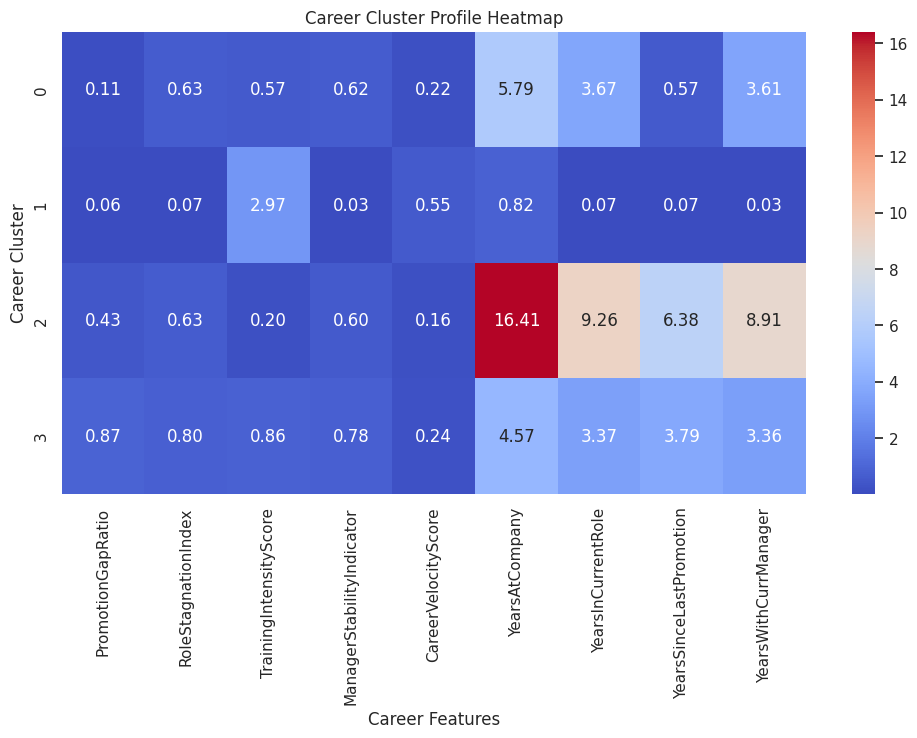

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate average career features for each cluster
cluster_profile = df.groupby('CareerCluster')[
    career_features
].mean()

# Plot the cluster profiles
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Career Cluster Profile Heatmap')
plt.xlabel('Career Features')
plt.ylabel('Career Cluster')

plt.show()

Step 6.4 — Analyze Attrition Across Career Clusters.

In [176]:
# Attrition count by career cluster
cluster_attrition = pd.crosstab(
    df['CareerCluster'],
    df['Attrition']
)

print("Attrition Count by Career Cluster:")
display(cluster_attrition)

Attrition Count by Career Cluster:


Attrition,0,1
CareerCluster,,
0,642,86
1,136,73
2,263,31
3,192,47


In [ ]:
# Calculate attrition rate for each cluster
cluster_attrition_rate = (
    df.groupby('CareerCluster')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
)

print("Attrition Rate by Career Cluster (%):")
display(cluster_attrition_rate)

Step 6.5 — Visualize the Attrition Rates

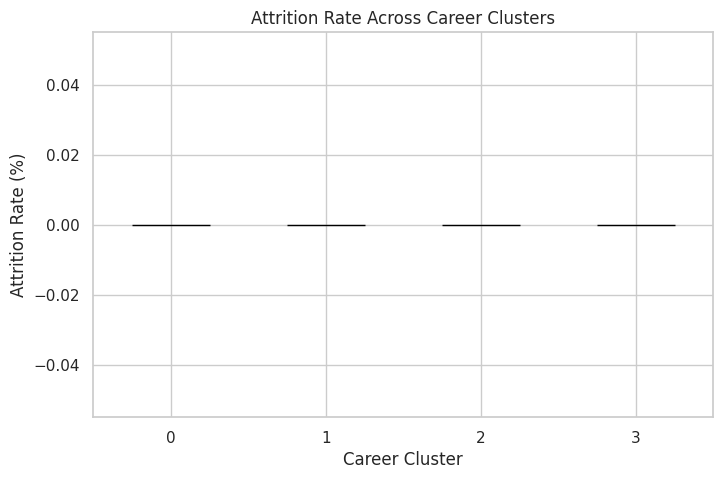

In [177]:
plt.figure(figsize=(8, 5))

cluster_attrition_rate.plot(
    kind='bar',
    edgecolor='black'
)

plt.xlabel('Career Cluster')
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate Across Career Clusters')
plt.xticks(rotation=0)

plt.show()

Step 7 — Give the clusters meaningful career-profile names.

Step 7.1 — Create a complete cluster summary


In [178]:
# Create a summary of each career cluster
cluster_summary = df.groupby('CareerCluster').agg(
    Employees=('CareerCluster', 'size'),
    Avg_PromotionGapRatio=('PromotionGapRatio', 'mean'),
    Avg_RoleStagnation=('RoleStagnationIndex', 'mean'),
    Avg_TrainingIntensity=('TrainingIntensityScore', 'mean'),
    Avg_ManagerStability=('ManagerStabilityIndicator', 'mean'),
    Avg_CareerVelocity=('CareerVelocityScore', 'mean'),
    Avg_YearsAtCompany=('YearsAtCompany', 'mean'),
    Avg_YearsInCurrentRole=('YearsInCurrentRole', 'mean'),
    Avg_YearsSincePromotion=('YearsSinceLastPromotion', 'mean'),
    Avg_YearsWithManager=('YearsWithCurrManager', 'mean')
).round(2)

display(cluster_summary)

,Employees,Avg_PromotionGapRatio,Avg_RoleStagnation,Avg_TrainingIntensity,Avg_ManagerStability,Avg_CareerVelocity,Avg_YearsAtCompany,Avg_YearsInCurrentRole,Avg_YearsSincePromotion,Avg_YearsWithManager
CareerCluster,,,,,,,,,,
0,728,0.11,0.63,0.57,0.62,0.22,5.79,3.67,0.57,3.61
1,209,0.06,0.07,2.97,0.03,0.55,0.82,0.07,0.07,0.03
2,294,0.43,0.63,0.20,0.60,0.16,16.41,9.26,6.38,8.91
3,239,0.87,0.80,0.86,0.78,0.24,4.57,3.37,3.79,3.36


Step 7.2 — Add attrition rate to the same summary


In [179]:
# Calculate attrition rate for each cluster
attrition_rate = (
    df.groupby('CareerCluster')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
    .rename('AttritionRate')
)

# Add attrition rate to cluster summary
cluster_summary = cluster_summary.join(attrition_rate)

display(cluster_summary)

,Employees,Avg_PromotionGapRatio,Avg_RoleStagnation,Avg_TrainingIntensity,Avg_ManagerStability,Avg_CareerVelocity,Avg_YearsAtCompany,Avg_YearsInCurrentRole,Avg_YearsSincePromotion,Avg_YearsWithManager,AttritionRate
CareerCluster,,,,,,,,,,,
0,728,0.11,0.63,0.57,0.62,0.22,5.79,3.67,0.57,3.61,0.0
1,209,0.06,0.07,2.97,0.03,0.55,0.82,0.07,0.07,0.03,0.0
2,294,0.43,0.63,0.20,0.60,0.16,16.41,9.26,6.38,8.91,0.0
3,239,0.87,0.80,0.86,0.78,0.24,4.57,3.37,3.79,3.36,0.0


Step 8 — Promotion Gap Risk Score.

Step 8.1 — Create a combined Promotion Gap Risk Score


In [180]:
# Create a combined Promotion Gap Risk Score

df['PromotionGapRiskScore'] = (
    0.6 * df['PromotionGapRatio'] +
    0.4 * df['RoleStagnationIndex']
)

print("Promotion Gap Risk Score created.")
display(
    df[
        [
            'PromotionGapRatio',
            'RoleStagnationIndex',
            'PromotionGapRiskScore'
        ]
    ].head()
)

Promotion Gap Risk Score created.


,PromotionGapRatio,RoleStagnationIndex,PromotionGapRiskScore
0,0.000,0.666667,0.266667
1,0.100,0.700000,0.340000
2,0.000,0.000000,0.000000
3,0.375,0.875000,0.575000
4,1.000,1.000000,1.000000


Step 8.2 — Convert the score into Low / Medium / High

In [181]:
# Calculate percentile thresholds

low_threshold = df['PromotionGapRiskScore'].quantile(0.33)
high_threshold = df['PromotionGapRiskScore'].quantile(0.67)

print("Low threshold:", round(low_threshold, 3))
print("High threshold:", round(high_threshold, 3))

Low threshold: 0.28
High threshold: 0.467


In [182]:
# Assign risk categories

def assign_risk(score):
    if score <= low_threshold:
        return 'Low'
    elif score <= high_threshold:
        return 'Medium'
    else:
        return 'High'

df['PromotionGapRisk'] = df['PromotionGapRiskScore'].apply(assign_risk)

print("Promotion Gap Risk categories:")
print(df['PromotionGapRisk'].value_counts())

Promotion Gap Risk categories:
PromotionGapRisk
Medium    516
Low       492
High      462
Name: count, dtype: int64


Step 8.3 — Visualize the distribution

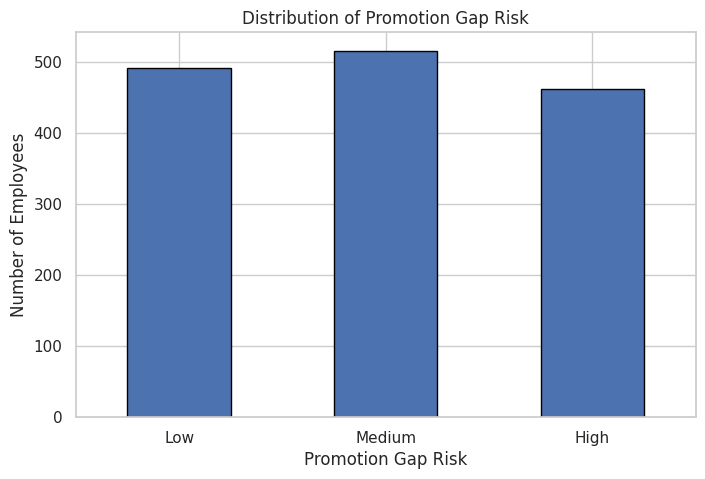

In [183]:
plt.figure(figsize=(8, 5))

df['PromotionGapRisk'].value_counts().reindex(
    ['Low', 'Medium', 'High']
).plot(kind='bar', edgecolor='black')

plt.xlabel('Promotion Gap Risk')
plt.ylabel('Number of Employees')
plt.title('Distribution of Promotion Gap Risk')
plt.xticks(rotation=0)

plt.show()

Step 9 — Retention Opportunity Index.

Step 9.1 — Create the Retention Opportunity Index

In [184]:
# Normalize the two additional career indicators
# so they can be combined with the risk score.

from sklearn.preprocessing import MinMaxScaler

retention_scaler = MinMaxScaler()

df[['RoleStagnation_Norm',
    'TrainingIntensity_Norm',
    'ManagerStability_Norm']] = retention_scaler.fit_transform(
    df[
        [
            'RoleStagnationIndex',
            'TrainingIntensityScore',
            'ManagerStabilityIndicator'
        ]
    ]
)

# Create Retention Opportunity Index
df['RetentionOpportunityIndex'] = (
    0.50 * df['PromotionGapRiskScore']
    + 0.30 * df['RoleStagnation_Norm']
    + 0.20 * (1 - df['TrainingIntensity_Norm'])
)

print("Retention Opportunity Index created.")

display(
    df[
        [
            'PromotionGapRiskScore',
            'RoleStagnation_Norm',
            'TrainingIntensity_Norm',
            'RetentionOpportunityIndex'
        ]
    ].head()
)

Retention Opportunity Index created.


,PromotionGapRiskScore,RoleStagnation_Norm,TrainingIntensity_Norm,RetentionOpportunityIndex
0,0.266667,0.666667,0.0000,0.533333
1,0.340000,0.700000,0.0500,0.570000
2,0.000000,0.000000,0.5000,0.100000
3,0.575000,0.875000,0.0625,0.737500
4,1.000000,1.000000,0.2500,0.950000


Step 9.2 — Categorize the index

In [185]:
# Create retention opportunity categories

low_opportunity = df['RetentionOpportunityIndex'].quantile(0.33)
high_opportunity = df['RetentionOpportunityIndex'].quantile(0.67)

def retention_category(score):
    if score <= low_opportunity:
        return 'Low'
    elif score <= high_opportunity:
        return 'Medium'
    else:
        return 'High'

df['RetentionOpportunity'] = (
    df['RetentionOpportunityIndex']
    .apply(retention_category)
)

print("Retention Opportunity Distribution:")
print(df['RetentionOpportunity'].value_counts())

Retention Opportunity Distribution:
RetentionOpportunity
Medium    495
Low       490
High      485
Name: count, dtype: int64


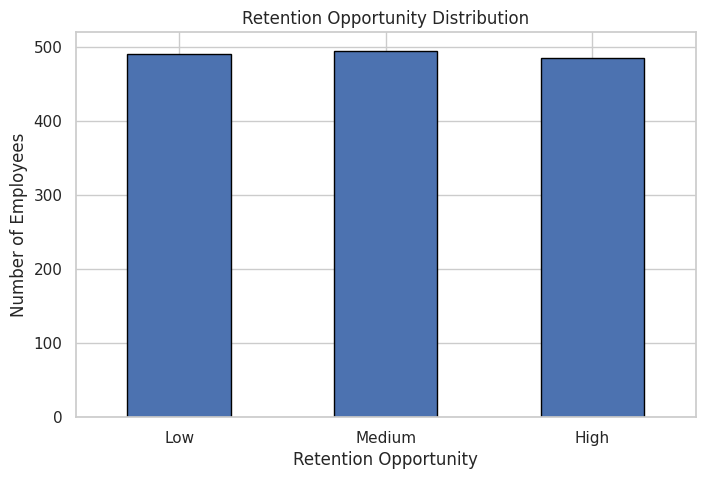

In [186]:
plt.figure(figsize=(8, 5))

df['RetentionOpportunity'].value_counts().reindex(
    ['Low', 'Medium', 'High']
).plot(
    kind='bar',
    edgecolor='black'
)

plt.xlabel('Retention Opportunity')
plt.ylabel('Number of Employees')
plt.title('Retention Opportunity Distribution')
plt.xticks(rotation=0)

plt.show()

Step 10 — Training Need Indicator.

Step 10.1 — Create Training Need Indicator

In [187]:
# Calculate the average training intensity
avg_training = df['TrainingIntensityScore'].median()

print("Median Training Intensity:", round(avg_training, 3))

Median Training Intensity: 0.5


In [188]:
# Create Training Need Indicator

df['TrainingNeedIndicator'] = np.where(
    df['TrainingIntensityScore'] < avg_training,
    'Needs Development',
    'Adequate'
)

print("Training Need Distribution:")
print(df['TrainingNeedIndicator'].value_counts())

Training Need Distribution:
TrainingNeedIndicator
Adequate             757
Needs Development    713
Name: count, dtype: int64


Step 10.2 — Visualize Training Need

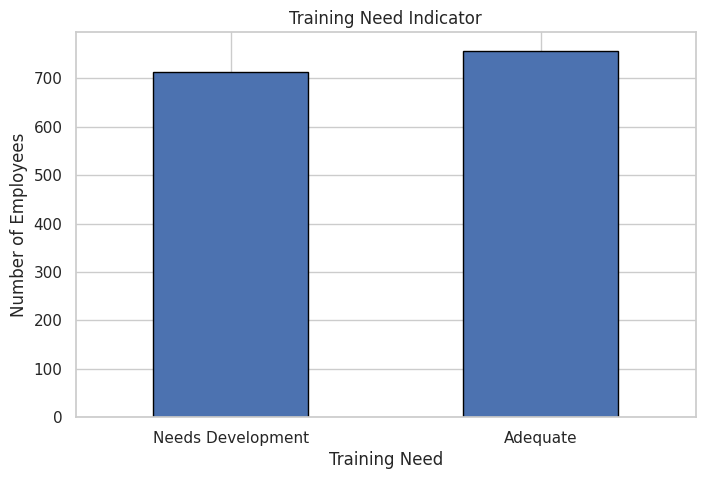

In [189]:
plt.figure(figsize=(8, 5))

df['TrainingNeedIndicator'].value_counts().reindex(
    ['Needs Development', 'Adequate']
).plot(
    kind='bar',
    edgecolor='black'
)

plt.xlabel('Training Need')
plt.ylabel('Number of Employees')
plt.title('Training Need Indicator')
plt.xticks(rotation=0)

plt.show()

Step 11 — Manager Stability Impact.

Step 11.1 — Create Manager Stability Categories

In [190]:
# Create manager stability categories based on the median

median_manager_stability = df['ManagerStabilityIndicator'].median()

print(
    "Median Manager Stability Indicator:",
    round(median_manager_stability, 3)
)

Median Manager Stability Indicator: 0.667


In [191]:
# Categorize manager stability

df['ManagerStability'] = np.where(
    df['ManagerStabilityIndicator'] < median_manager_stability,
    'Lower Stability',
    'Higher Stability'
)

print("Manager Stability Distribution:")
print(df['ManagerStability'].value_counts())

Manager Stability Distribution:
ManagerStability
Higher Stability    751
Lower Stability     719
Name: count, dtype: int64


Step 11.2 — Compare promotion-gap risk

In [192]:
manager_impact = df.groupby('ManagerStability').agg(
    Employees=('ManagerStability', 'size'),
    Avg_PromotionGapRisk=('PromotionGapRiskScore', 'mean'),
    Avg_RoleStagnation=('RoleStagnationIndex', 'mean'),
    Avg_YearsWithManager=('YearsWithCurrManager', 'mean')
).round(2)

display(manager_impact)

,Employees,Avg_PromotionGapRisk,Avg_RoleStagnation,Avg_YearsWithManager
ManagerStability,,,,
Higher Stability,751,0.49,0.69,5.42
Lower Stability,719,0.32,0.47,2.77


Step 11.3 — Compare attrition

In [193]:
manager_attrition = (
    df.groupby('ManagerStability')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
    .rename('AttritionRate')
)

display(manager_attrition)

,AttritionRate
ManagerStability,
Higher Stability,0.0
Lower Stability,0.0


Step 12 — Final Career Progression KPI Table.

Step 12.1 — Create the employee-level KPI table

In [194]:
# ==========================================
# STEP 12: FINAL CAREER PROGRESSION KPI TABLE
# ==========================================

kpi_columns = [
    'CareerCluster',
    'PromotionGapRiskScore',
    'PromotionGapRisk',
    'RetentionOpportunityIndex',
    'RetentionOpportunity',
    'TrainingNeedIndicator',
    'ManagerStability',
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'CareerVelocityScore',
    'CareerStage',
    'Attrition'
]

career_kpi_table = df[kpi_columns].copy()

print("Final KPI table shape:", career_kpi_table.shape)

display(career_kpi_table.head(10))

Final KPI table shape: (1470, 14)


,CareerCluster,PromotionGapRiskScore,PromotionGapRisk,RetentionOpportunityIndex,RetentionOpportunity,TrainingNeedIndicator,ManagerStability,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,CareerStage,Attrition
0,0,0.266667,Low,0.533333,Medium,Needs Development,Higher Stability,0.000000,0.666667,0.000000,0.833333,0.250000,Growth Stage,1
1,0,0.340000,Medium,0.570000,Medium,Needs Development,Higher Stability,0.100000,0.700000,0.300000,0.700000,0.200000,Mid Career,0
2,1,0.000000,Low,0.100000,Low,Adequate,Lower Stability,0.000000,0.000000,3.000000,0.000000,0.142857,Early Career,1
3,0,0.575000,High,0.737500,High,Needs Development,Lower Stability,0.375000,0.875000,0.375000,0.000000,0.125000,Mid Career,0
4,3,1.000000,High,0.950000,High,Adequate,Higher Stability,1.000000,1.000000,1.500000,1.000000,0.166667,Early Career,0
5,3,0.657143,High,0.819048,High,Needs Development,Higher Stability,0.428571,1.000000,0.285714,0.857143,0.125000,Mid Career,0
6,1,0.000000,Low,0.100000,Low,Adequate,Lower Stability,0.000000,0.000000,3.000000,0.000000,0.083333,Early Career,0
7,1,0.000000,Low,0.133333,Low,Adequate,Lower Stability,0.000000,0.000000,2.000000,0.000000,1.000000,Early Career,0
8,0,0.377778,Medium,0.614815,Medium,Needs Development,Higher Stability,0.111111,0.777778,0.222222,0.888889,0.300000,Mid Career,0
9,3,1.000000,High,0.985714,High,Needs Development,Higher Stability,1.000000,1.000000,0.428571,1.000000,0.117647,Mid Career,0


Step 12.2 — Get an overall KPI summary

In [195]:
print("========== KPI SUMMARY ==========\n")

print("Promotion Gap Risk:")
display(df['PromotionGapRisk'].value_counts())

print("\nRetention Opportunity:")
display(df['RetentionOpportunity'].value_counts())

print("\nTraining Need:")
display(df['TrainingNeedIndicator'].value_counts())

print("\nManager Stability:")
display(df['ManagerStability'].value_counts())

========== KPI SUMMARY ==========

Promotion Gap Risk:


,count
PromotionGapRisk,
Medium,516
Low,492
High,462



Retention Opportunity:


,count
RetentionOpportunity,
Medium,495
Low,490
High,485



Training Need:


,count
TrainingNeedIndicator,
Adequate,757
Needs Development,713



Manager Stability:


,count
ManagerStability,
Higher Stability,751
Lower Stability,719


Step 13 — Hierarchical Clustering.

Step 13.1 — Perform Hierarchical Clustering

In [196]:
from sklearn.cluster import AgglomerativeClustering

# Create hierarchical clustering model
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

# Generate cluster labels
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Store the labels in the dataframe
df['HierarchicalCluster'] = hierarchical_labels

print("Hierarchical clustering completed.")

print("\nHierarchical Cluster Distribution:")
print(
    df['HierarchicalCluster']
    .value_counts()
    .sort_index()
)

Hierarchical clustering completed.

Hierarchical Cluster Distribution:
HierarchicalCluster
0    405
1    211
2    238
3    616
Name: count, dtype: int64


Step 13.2 — Compare the two clustering methods

In [197]:
cluster_comparison = pd.crosstab(
    df['CareerCluster'],
    df['HierarchicalCluster']
)

print("K-Means vs Hierarchical Clustering:")
display(cluster_comparison)

K-Means vs Hierarchical Clustering:


HierarchicalCluster,0,1,2,3
CareerCluster,,,,
0,146,1,3,578
1,0,209,0,0
2,249,0,38,7
3,10,1,197,31


Step 13.3 — Calculate agreement between the methods

In [198]:
from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(
    df['CareerCluster'],
    df['HierarchicalCluster']
)

print("Adjusted Rand Index:", round(ari_score, 3))

Adjusted Rand Index: 0.617


Step 14 — Validate the Clustering Results

Step 14.1 — View the ARI score

In [199]:
print("Adjusted Rand Index (ARI):", round(ari_score, 3))

Adjusted Rand Index (ARI): 0.617


Step 14.2 — Compare cluster sizes

In [200]:
# Compare cluster sizes from both methods

comparison_sizes = pd.DataFrame({
    'KMeans': df['CareerCluster'].value_counts().sort_index(),
    'Hierarchical': df['HierarchicalCluster'].value_counts().sort_index()
})

display(comparison_sizes)

,KMeans,Hierarchical
0,728,405
1,209,211
2,294,238
3,239,616


Step 14.3 — Compare the career characteristics

In [201]:
hierarchical_profile = df.groupby('HierarchicalCluster')[
    career_features
].mean().round(2)

print("Hierarchical Cluster Profiles:")
display(hierarchical_profile)

Hierarchical Cluster Profiles:


,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
HierarchicalCluster,,,,,,,,,
0,0.26,0.69,0.24,0.68,0.17,14.18,8.60,4.10,8.44
1,0.07,0.07,2.95,0.03,0.55,0.83,0.07,0.08,0.03
2,0.89,0.79,0.82,0.82,0.24,5.07,3.73,4.30,4.08
3,0.15,0.59,0.63,0.56,0.22,5.16,2.97,0.83,2.70


In [202]:
print("K-Means Cluster Profiles:")
display(cluster_profile.round(2))

K-Means Cluster Profiles:


,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
CareerCluster,,,,,,,,,
0,0.11,0.63,0.57,0.62,0.22,5.79,3.67,0.57,3.61
1,0.06,0.07,2.97,0.03,0.55,0.82,0.07,0.07,0.03
2,0.43,0.63,0.20,0.60,0.16,16.41,9.26,6.38,8.91
3,0.87,0.80,0.86,0.78,0.24,4.57,3.37,3.79,3.36


Step 14.4 — Final validation statement

"K-Means clustering was validated using agglomerative hierarchical clustering. The resulting cluster assignments were compared using the Adjusted Rand Index, while cluster-level career characteristics were examined to assess whether similar career progression patterns emerged across methods."

Step 15 — Final Career Cluster Interpretation

Step 15.1 — Display the key indicators

In [203]:
# Key indicators for interpreting career clusters

interpretation_features = [
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'CareerVelocityScore',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

cluster_interpretation = (
    df.groupby('CareerCluster')[interpretation_features]
    .mean()
    .round(2)
)

display(cluster_interpretation)

,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
CareerCluster,,,,,,,,,
0,0.11,0.63,0.57,0.62,0.22,5.79,3.67,0.57,3.61
1,0.06,0.07,2.97,0.03,0.55,0.82,0.07,0.07,0.03
2,0.43,0.63,0.20,0.60,0.16,16.41,9.26,6.38,8.91
3,0.87,0.80,0.86,0.78,0.24,4.57,3.37,3.79,3.36


Step 15.2 — Add employee count and attrition

In [204]:
cluster_interpretation['Employees'] = (
    df['CareerCluster'].value_counts()
)

cluster_interpretation['AttritionRate'] = (
    df.groupby('CareerCluster')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
)

display(
    cluster_interpretation
    .sort_index()
)

,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Employees,AttritionRate
CareerCluster,,,,,,,,,,,
0,0.11,0.63,0.57,0.62,0.22,5.79,3.67,0.57,3.61,728,0.0
1,0.06,0.07,2.97,0.03,0.55,0.82,0.07,0.07,0.03,209,0.0
2,0.43,0.63,0.20,0.60,0.16,16.41,9.26,6.38,8.91,294,0.0
3,0.87,0.80,0.86,0.78,0.24,4.57,3.37,3.79,3.36,239,0.0


Step 15.3 — Automatically identify the strongest indicators

In [205]:
# Rank clusters for the major career indicators

for feature in [
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'CareerVelocityScore'
]:
    print(f"\nHighest {feature}:")
    print(
        cluster_interpretation[feature]
        .sort_values(ascending=False)
    )


Highest PromotionGapRatio:
CareerCluster
3    0.87
2    0.43
0    0.11
1    0.06
Name: PromotionGapRatio, dtype: float64

Highest RoleStagnationIndex:
CareerCluster
3    0.80
0    0.63
2    0.63
1    0.07
Name: RoleStagnationIndex, dtype: float64

Highest TrainingIntensityScore:
CareerCluster
1    2.97
3    0.86
0    0.57
2    0.20
Name: TrainingIntensityScore, dtype: float64

Highest ManagerStabilityIndicator:
CareerCluster
3    0.78
0    0.62
2    0.60
1    0.03
Name: ManagerStabilityIndicator, dtype: float64

Highest CareerVelocityScore:
CareerCluster
1    0.55
3    0.24
0    0.22
2    0.16
Name: CareerVelocityScore, dtype: float64


Step 16 — Identify Retention Opportunity Employees

Now we'll use the KPIs we've created to identify employees who may benefit from proactive career-development attention.

We'll focus on employees with:

High Promotion Gap Risk
High Retention Opportunity
Observed as still employed (Attrition = No)
Step 16.1 — Create the retention-opportunity group

In [206]:
# Identify employees who are still with the company
# and have high career-stagnation indicators

retention_opportunities = df[
    (df['Attrition'] == 'No') &
    (df['PromotionGapRisk'] == 'High') &
    (df['RetentionOpportunity'] == 'High')
].copy()

print(
    "Number of employees identified as retention opportunities:",
    len(retention_opportunities)
)

Number of employees identified as retention opportunities: 0


Step 16.2 — Examine their career characteristics

In [207]:
retention_profile = retention_opportunities[
    [
        'CareerCluster',
        'CareerStage',
        'PromotionGapRatio',
        'RoleStagnationIndex',
        'TrainingIntensityScore',
        'ManagerStabilityIndicator',
        'CareerVelocityScore',
        'YearsAtCompany',
        'YearsInCurrentRole',
        'YearsSinceLastPromotion',
        'YearsWithCurrManager'
    ]
].copy()

display(retention_profile.head(20))

,CareerCluster,CareerStage,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


Step 16.3 — Summarize the retention-opportunity group

In [208]:
retention_summary = retention_opportunities.agg({
    'PromotionGapRatio': 'mean',
    'RoleStagnationIndex': 'mean',
    'TrainingIntensityScore': 'mean',
    'ManagerStabilityIndicator': 'mean',
    'CareerVelocityScore': 'mean',
    'YearsAtCompany': 'mean',
    'YearsInCurrentRole': 'mean',
    'YearsSinceLastPromotion': 'mean',
    'YearsWithCurrManager': 'mean'
}).round(2)

display(retention_summary)

,0
PromotionGapRatio,NaN
RoleStagnationIndex,NaN
TrainingIntensityScore,NaN
ManagerStabilityIndicator,NaN
CareerVelocityScore,NaN
YearsAtCompany,NaN
YearsInCurrentRole,NaN
YearsSinceLastPromotion,NaN
YearsWithCurrManager,NaN


Step 16.4 — See which career clusters contain these employees

In [147]:
cluster_retention = (
    retention_opportunities['CareerCluster']
    .value_counts()
    .sort_index()
)

print("Retention Opportunities by Career Cluster:")
display(cluster_retention)

Retention Opportunities by Career Cluster:


,count
CareerCluster,


Step 17 — Department & Job Role Analysis

Step 17.1 — Department analysis

In [148]:
# Retention opportunities by department

department_retention = (
    retention_opportunities['Department']
    .value_counts()
    .sort_values(ascending=False)
)

print("Retention Opportunities by Department:")
display(department_retention)

Retention Opportunities by Department:


,count
Department,


Step 17.2 — Calculate the percentage within each department

In [149]:
# Total employees in each department
department_total = df['Department'].value_counts()

# Retention opportunities as percentage of each department
department_retention_rate = (
    department_retention / department_total * 100
).round(2)

print("Retention Opportunity Rate by Department (%):")
display(department_retention_rate.sort_values(ascending=False))

Retention Opportunity Rate by Department (%):


,count
Department,
Human Resources,NaN
Research & Development,NaN
Sales,NaN


Step 17.3 — Job-role analysis

In [150]:
# Retention opportunities by job role

role_retention = (
    retention_opportunities['JobRole']
    .value_counts()
    .sort_values(ascending=False)
)

print("Retention Opportunities by Job Role:")
display(role_retention)

Retention Opportunities by Job Role:


,count
JobRole,


In [151]:
# Total employees in each job role
role_total = df['JobRole'].value_counts()

# Retention opportunity percentage within each role
role_retention_rate = (
    role_retention / role_total * 100
).round(2)

print("Retention Opportunity Rate by Job Role (%):")
display(role_retention_rate.sort_values(ascending=False))

Retention Opportunity Rate by Job Role (%):


,count
JobRole,
Healthcare Representative,NaN
Human Resources,NaN
Laboratory Technician,NaN
Manager,NaN
Manufacturing Director,NaN
Research Director,NaN
Research Scientist,NaN
Sales Executive,NaN
Sales Representative,NaN


Step 17.4 — Visualize the department results

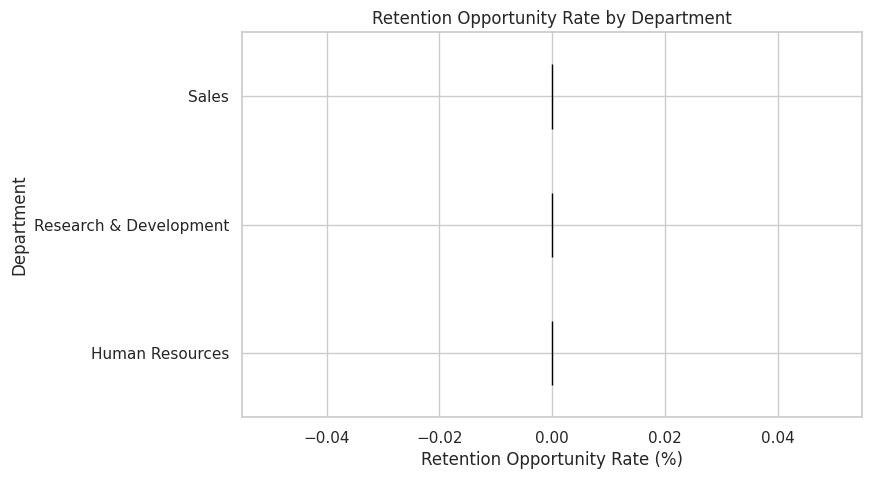

In [152]:
plt.figure(figsize=(8, 5))

department_retention_rate.sort_values().plot(
    kind='barh',
    edgecolor='black'
)

plt.xlabel('Retention Opportunity Rate (%)')
plt.ylabel('Department')
plt.title('Retention Opportunity Rate by Department')

plt.show()

Step 18 — Career Stage Analysis

Step 18.1 — Analyze promotion-gap risk by career stage

In [209]:
career_stage_analysis = df.groupby('CareerStage').agg(
    Employees=('CareerStage', 'size'),
    Avg_PromotionGapRisk=('PromotionGapRiskScore', 'mean'),
    Avg_RoleStagnation=('RoleStagnationIndex', 'mean'),
    Avg_YearsAtCompany=('YearsAtCompany', 'mean'),
    Avg_YearsSincePromotion=('YearsSinceLastPromotion', 'mean')
).round(2)

display(career_stage_analysis)

,Employees,Avg_PromotionGapRisk,Avg_RoleStagnation,Avg_YearsAtCompany,Avg_YearsSincePromotion
CareerStage,,,,,
Early Career,342,0.37,0.39,1.24,0.66
Growth Stage,510,0.34,0.59,4.43,0.74
Mid Career,460,0.51,0.73,9.33,3.27
Senior Career,158,0.40,0.50,21.04,7.00


Step 18.2 — Retention opportunities by career stage

In [210]:
career_stage_retention = (
    retention_opportunities['CareerStage']
    .value_counts()
)

career_stage_total = df['CareerStage'].value_counts()

career_stage_retention_rate = (
    career_stage_retention / career_stage_total * 100
).round(2)

print("Retention Opportunity Rate by Career Stage (%):")
display(
    career_stage_retention_rate
    .sort_values(ascending=False)
)

Retention Opportunity Rate by Career Stage (%):


,count
CareerStage,
Early Career,NaN
Growth Stage,NaN
Mid Career,NaN
Senior Career,NaN


Step 18.3 — Visualize

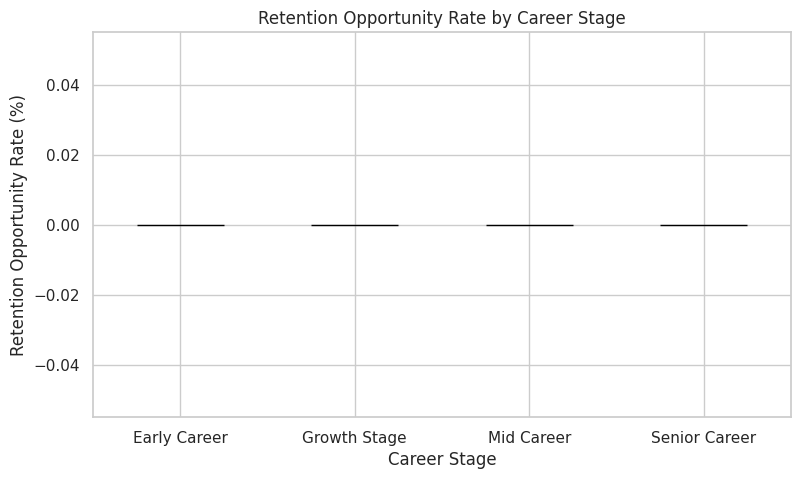

In [211]:
plt.figure(figsize=(9, 5))

career_stage_retention_rate.reindex(
    ['Early Career', 'Growth Stage', 'Mid Career', 'Senior Career']
).plot(
    kind='bar',
    edgecolor='black'
)

plt.xlabel('Career Stage')
plt.ylabel('Retention Opportunity Rate (%)')
plt.title('Retention Opportunity Rate by Career Stage')
plt.xticks(rotation=0)

plt.show()

Step 19 — Final Management Insights Table

Step 19.1 — Create the management insights table

In [212]:
# ==========================================
# STEP 19: MANAGEMENT INSIGHTS TABLE
# ==========================================

management_insights = df[
    [
        'Department',
        'JobRole',
        'CareerStage',
        'CareerCluster',
        'PromotionGapRisk',
        'RetentionOpportunity',
        'TrainingNeedIndicator',
        'ManagerStability',
        'PromotionGapRatio',
        'RoleStagnationIndex',
        'YearsAtCompany',
        'YearsInCurrentRole',
        'YearsSinceLastPromotion',
        'YearsWithCurrManager',
        'Attrition'
    ]
].copy()

print("Management insights table shape:", management_insights.shape)

display(management_insights.head(10))

Management insights table shape: (1470, 15)


,Department,JobRole,CareerStage,CareerCluster,PromotionGapRisk,RetentionOpportunity,TrainingNeedIndicator,ManagerStability,PromotionGapRatio,RoleStagnationIndex,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,Sales,Sales Executive,Growth Stage,0,Low,Medium,Needs Development,Higher Stability,0.000000,0.666667,6,4,0,5,1
1,Research & Development,Research Scientist,Mid Career,0,Medium,Medium,Needs Development,Higher Stability,0.100000,0.700000,10,7,1,7,0
2,Research & Development,Laboratory Technician,Early Career,1,Low,Low,Adequate,Lower Stability,0.000000,0.000000,0,0,0,0,1
3,Research & Development,Research Scientist,Mid Career,0,High,High,Needs Development,Lower Stability,0.375000,0.875000,8,7,3,0,0
4,Research & Development,Laboratory Technician,Early Career,3,High,High,Adequate,Higher Stability,1.000000,1.000000,2,2,2,2,0
5,Research & Development,Laboratory Technician,Mid Career,3,High,High,Needs Development,Higher Stability,0.428571,1.000000,7,7,3,6,0
6,Research & Development,Laboratory Technician,Early Career,1,Low,Low,Adequate,Lower Stability,0.000000,0.000000,1,0,0,0,0
7,Research & Development,Laboratory Technician,Early Career,1,Low,Low,Adequate,Lower Stability,0.000000,0.000000,1,0,0,0,0
8,Research & Development,Manufacturing Director,Mid Career,0,Medium,Medium,Needs Development,Higher Stability,0.111111,0.777778,9,7,1,8,0
9,Research & Development,Healthcare Representative,Mid Career,3,High,High,Needs Development,Higher Stability,1.000000,1.000000,7,7,7,7,0


Step 19.2 — Create a management summary by department

In [213]:
department_summary = df.groupby('Department').agg(
    Employees=('Department', 'size'),
    Avg_PromotionGapRisk=('PromotionGapRiskScore', 'mean'),
    Avg_RoleStagnation=('RoleStagnationIndex', 'mean'),
    Avg_TrainingIntensity=('TrainingIntensityScore', 'mean'),
    Avg_ManagerStability=('ManagerStabilityIndicator', 'mean'),
    Retention_Opportunities=(
        'RetentionOpportunity',
        lambda x: (x == 'High').sum()
    ),
    Training_Needs=(
        'TrainingNeedIndicator',
        lambda x: (x == 'Needs Development').sum()
    ),
    AttritionRate=(
        'Attrition',
        lambda x: (x == 'Yes').mean() * 100
    )
).round(2)

display(department_summary)

,Employees,Avg_PromotionGapRisk,Avg_RoleStagnation,Avg_TrainingIntensity,Avg_ManagerStability,Retention_Opportunities,Training_Needs,AttritionRate
Department,,,,,,,,
Human Resources,63,0.39,0.55,0.70,0.54,22,32,0.0
Research & Development,961,0.40,0.57,0.90,0.56,295,459,0.0
Sales,446,0.42,0.59,0.88,0.56,168,222,0.0


Step 19.3 — Sort departments by retention opportunities

In [215]:
department_summary_sorted = department_summary.sort_values(
    'Retention_Opportunities',
    ascending=False
)

display(department_summary_sorted)

,Employees,Avg_PromotionGapRisk,Avg_RoleStagnation,Avg_TrainingIntensity,Avg_ManagerStability,Retention_Opportunities,Training_Needs,AttritionRate
Department,,,,,,,,
Research & Development,961,0.40,0.57,0.90,0.56,295,459,0.0
Sales,446,0.42,0.59,0.88,0.56,168,222,0.0
Human Resources,63,0.39,0.55,0.70,0.54,22,32,0.0


Step 20 — Export the Final Processed Dataset

20.1 — Create the final dataset

In [214]:
# Step 20 — Export final processed dataset

output_columns = [
    # Original employee information
    'Age',
    'Attrition',
    'Department',
    'JobRole',

    # Career progression features
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'CareerVelocityScore',
    'SalaryGrowthProxy',
    'CareerStage',

    # Clustering results
    'CareerCluster',
    'HierarchicalCluster',

    # Risk and retention indicators
    'PromotionGapRiskScore',
    'PromotionGapRisk',
    'RetentionOpportunityIndex',
    'RetentionOpportunity',
    'TrainingNeedIndicator',
    'ManagerStability'
]

# Keep only columns that actually exist in the dataframe
output_columns = [col for col in output_columns if col in df.columns]

final_dataset = df[output_columns].copy()

print("Final dataset created successfully.")
print("Shape:", final_dataset.shape)

display(final_dataset.head(10))

Final dataset created successfully.
Shape: (1470, 19)


,Age,Attrition,Department,JobRole,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,SalaryGrowthProxy,CareerStage,CareerCluster,HierarchicalCluster,PromotionGapRiskScore,PromotionGapRisk,RetentionOpportunityIndex,RetentionOpportunity,TrainingNeedIndicator,ManagerStability
0,41,1,Sales,Sales Executive,0.000000,0.666667,0.000000,0.833333,0.250000,22,Growth Stage,0,3,0.266667,Low,0.533333,Medium,Needs Development,Higher Stability
1,49,0,Research & Development,Research Scientist,0.100000,0.700000,0.300000,0.700000,0.200000,46,Mid Career,0,0,0.340000,Medium,0.570000,Medium,Needs Development,Higher Stability
2,37,1,Research & Development,Laboratory Technician,0.000000,0.000000,3.000000,0.000000,0.142857,15,Early Career,1,1,0.000000,Low,0.100000,Low,Adequate,Lower Stability
3,33,0,Research & Development,Research Scientist,0.375000,0.875000,0.375000,0.000000,0.125000,11,Mid Career,0,3,0.575000,High,0.737500,High,Needs Development,Lower Stability
4,27,0,Research & Development,Laboratory Technician,1.000000,1.000000,1.500000,1.000000,0.166667,12,Early Career,3,2,1.000000,High,0.950000,High,Adequate,Higher Stability
5,32,0,Research & Development,Laboratory Technician,0.428571,1.000000,0.285714,0.857143,0.125000,13,Mid Career,3,0,0.657143,High,0.819048,High,Needs Development,Higher Stability
6,59,0,Research & Development,Laboratory Technician,0.000000,0.000000,3.000000,0.000000,0.083333,20,Early Career,1,1,0.000000,Low,0.100000,Low,Adequate,Lower Stability
7,30,0,Research & Development,Laboratory Technician,0.000000,0.000000,2.000000,0.000000,1.000000,22,Early Career,1,1,0.000000,Low,0.133333,Low,Adequate,Lower Stability
8,38,0,Research & Development,Manufacturing Director,0.111111,0.777778,0.222222,0.888889,0.300000,63,Mid Career,0,0,0.377778,Medium,0.614815,Medium,Needs Development,Higher Stability
9,36,0,Research & Development,Healthcare Representative,1.000000,1.000000,0.428571,1.000000,0.117647,26,Mid Career,3,2,1.000000,High,0.985714,High,Needs Development,Higher Stability


20.2 — Export it as CSV

In [216]:
final_dataset.to_csv(
    'Palo_Alto_Career_Progression_Analysis.csv',
    index=False
)

print("Final dataset exported successfully.")

Final dataset exported successfully.


20.3 — Download it to your computer

In [217]:
from google.colab import files

files.download('Palo_Alto_Career_Progression_Analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Step 21 — Final Visualization & Insights

21.1 — Career Cluster Distribution

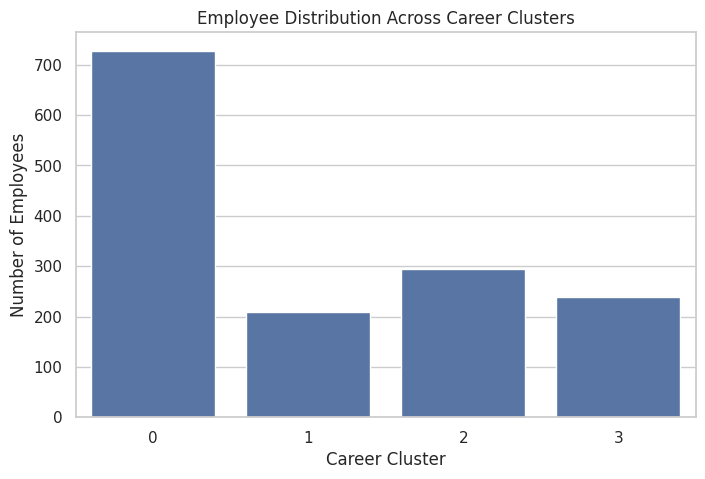

In [218]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='CareerCluster'
)

plt.title('Employee Distribution Across Career Clusters')
plt.xlabel('Career Cluster')
plt.ylabel('Number of Employees')

plt.show()

21.2 — Promotion Gap Risk Distribution

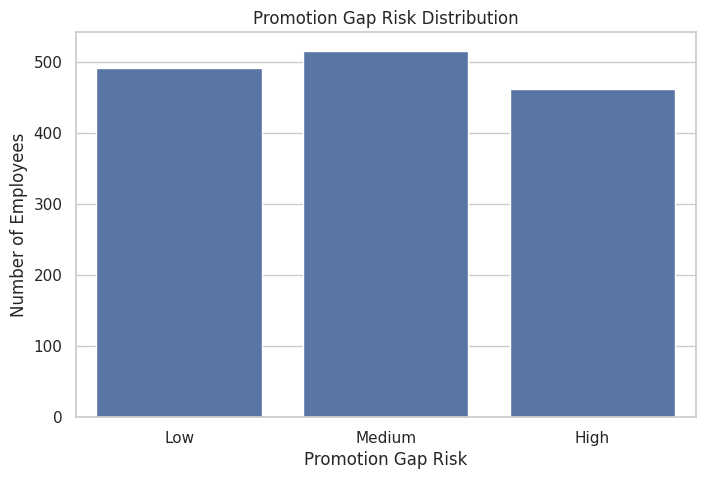

In [219]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='PromotionGapRisk',
    order=['Low', 'Medium', 'High']
)

plt.title('Promotion Gap Risk Distribution')
plt.xlabel('Promotion Gap Risk')
plt.ylabel('Number of Employees')

plt.show()

21.3 — Retention Opportunities by Department

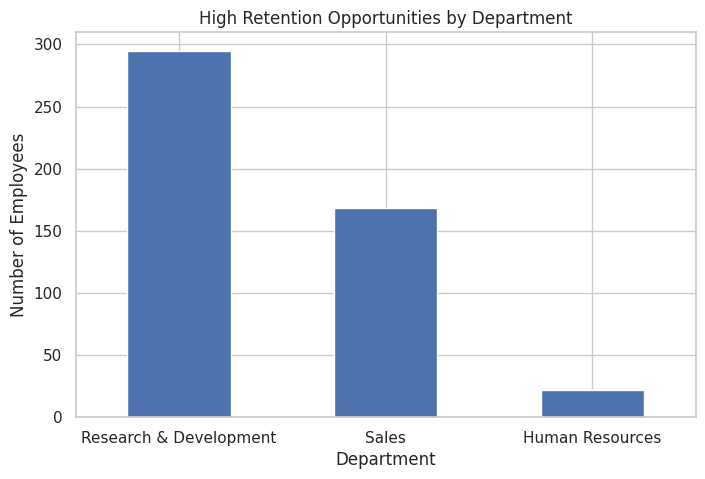

In [220]:
retention_department = (
    df[df['RetentionOpportunity'] == 'High']
    ['Department']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

retention_department.plot(kind='bar')

plt.title('High Retention Opportunities by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')

plt.xticks(rotation=0)

plt.show()

21.4 — Retention Opportunities by Career Stage

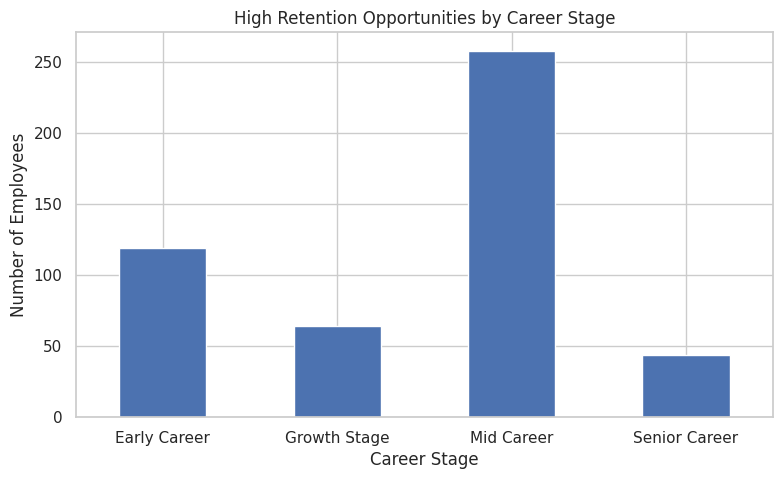

In [221]:
career_stage_order = [
    'Early Career',
    'Growth Stage',
    'Mid Career',
    'Senior Career'
]

retention_stage = (
    df[df['RetentionOpportunity'] == 'High']
    ['CareerStage']
    .value_counts()
    .reindex(career_stage_order, fill_value=0)
)

plt.figure(figsize=(9, 5))

retention_stage.plot(kind='bar')

plt.title('High Retention Opportunities by Career Stage')
plt.xlabel('Career Stage')
plt.ylabel('Number of Employees')

plt.xticks(rotation=0)

plt.show()

Step 21.5 — Career Cluster Profile Heatmap

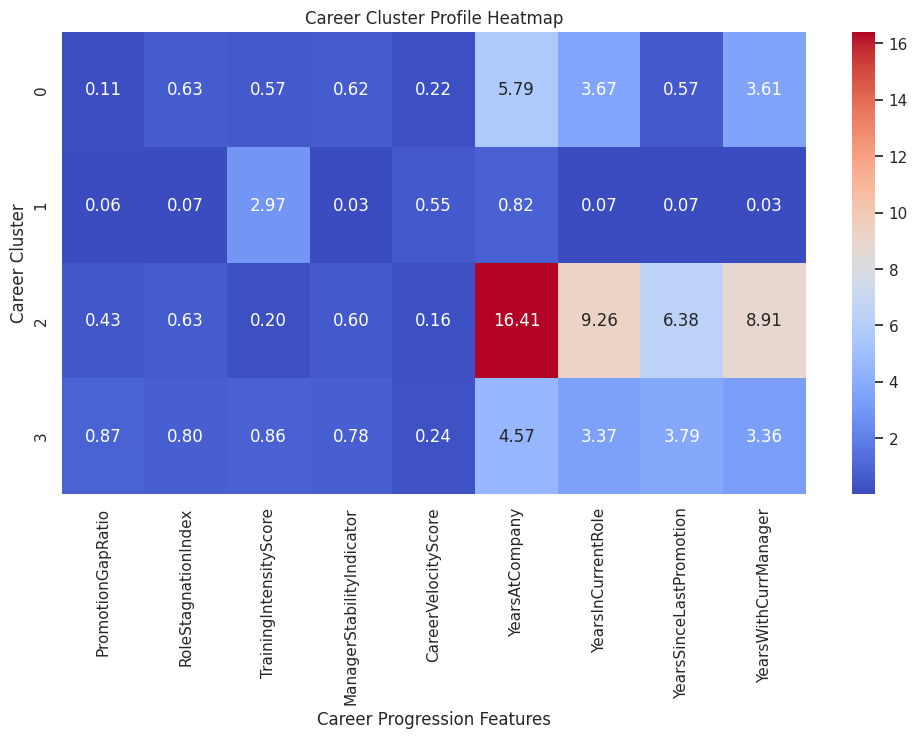

In [222]:
# Step 21.5 — Career Cluster Profile Heatmap

cluster_profile = df.groupby('CareerCluster')[
    career_features
].mean()

plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Career Cluster Profile Heatmap')
plt.xlabel('Career Progression Features')
plt.ylabel('Career Cluster')

plt.show()

Step 21.6 — Attrition Rate by Career Cluster

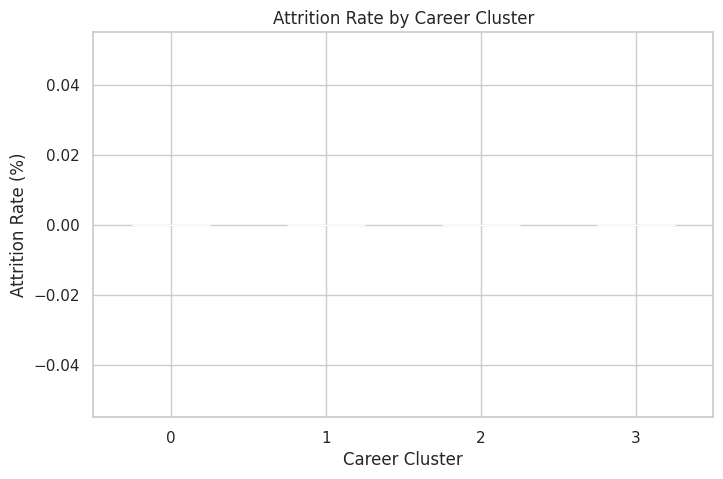

In [223]:
# Step 21.6 — Attrition Rate by Career Cluster

cluster_attrition_rate = (
    df.groupby('CareerCluster')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
)

plt.figure(figsize=(8, 5))

cluster_attrition_rate.plot(kind='bar')

plt.title('Attrition Rate by Career Cluster')
plt.xlabel('Career Cluster')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=0)

plt.show()

Step 21.7 — Promotion Gap Risk by Department

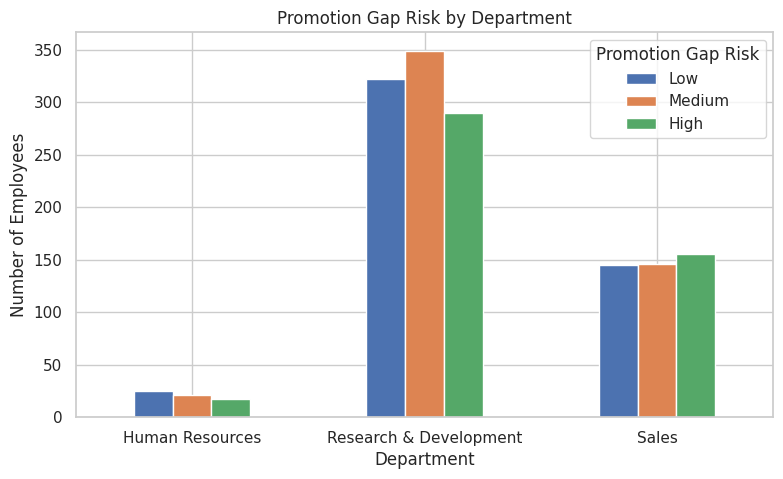

In [224]:
# Step 21.7 — Promotion Gap Risk by Department

promotion_risk_department = pd.crosstab(
    df['Department'],
    df['PromotionGapRisk']
)

# Keep the risk categories in the correct order
promotion_risk_department = promotion_risk_department.reindex(
    columns=['Low', 'Medium', 'High'],
    fill_value=0
)

promotion_risk_department.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Promotion Gap Risk by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')

plt.xticks(rotation=0)
plt.legend(title='Promotion Gap Risk')

plt.show()

Step 21.8 — Training Need by Department

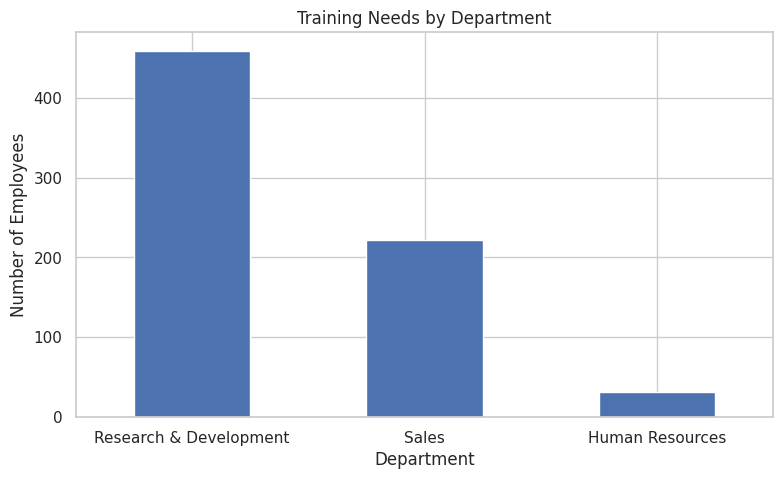

In [225]:
# Step 21.8 — Training Need by Department

training_need_department = (
    df[df['TrainingNeedIndicator'] == 'Needs Development']
    ['Department']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

training_need_department.plot(kind='bar')

plt.title('Training Needs by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')

plt.xticks(rotation=0)

plt.show()

Step 21.9 — Manager Stability vs Promotion Gap Risk

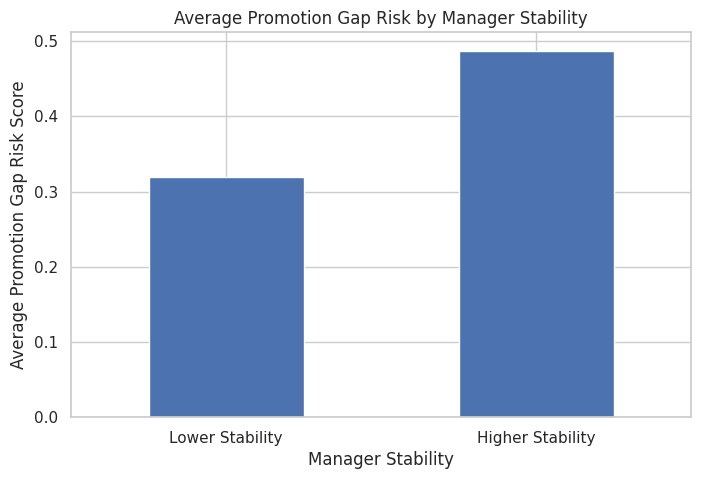

In [226]:
# Step 21.9 — Manager Stability vs Promotion Gap Risk

manager_risk = (
    df.groupby('ManagerStability')['PromotionGapRiskScore']
    .mean()
    .reindex(['Lower Stability', 'Higher Stability'])
)

plt.figure(figsize=(8, 5))

manager_risk.plot(kind='bar')

plt.title('Average Promotion Gap Risk by Manager Stability')
plt.xlabel('Manager Stability')
plt.ylabel('Average Promotion Gap Risk Score')

plt.xticks(rotation=0)

plt.show()

Step 22 — Final Project Findings & Management Insights

Step 22.1 — Overall Project Summary

In [227]:
# Step 22.1 — Overall Project Summary

project_summary = pd.DataFrame({
    'Metric': [
        'Total Employees',
        'Attrition Rate (%)',
        'Number of Career Clusters',
        'High Promotion Gap Risk',
        'High Retention Opportunities',
        'Employees Needing Development',
        'Lower Manager Stability',
        'Higher Manager Stability'
    ],
    'Value': [
        len(df),

        round(
            (df['Attrition'] == 'Yes').mean() * 100,
            2
        ),

        df['CareerCluster'].nunique(),

        (df['PromotionGapRisk'] == 'High').sum(),

        (df['RetentionOpportunity'] == 'High').sum(),

        (df['TrainingNeedIndicator'] == 'Needs Development').sum(),

        (df['ManagerStability'] == 'Lower Stability').sum(),

        (df['ManagerStability'] == 'Higher Stability').sum()
    ]
})

display(project_summary)

,Metric,Value
0,Total Employees,1470.0
1,Attrition Rate (%),0.0
2,Number of Career Clusters,4.0
3,High Promotion Gap Risk,462.0
4,High Retention Opportunities,485.0
5,Employees Needing Development,713.0
6,Lower Manager Stability,719.0
7,Higher Manager Stability,751.0


Step 22.2 — Career Cluster Interpretation

In [228]:
# Step 22.2 — Career Cluster Interpretation

cluster_interpretation = df.groupby('CareerCluster').agg(
    Employees=('CareerCluster', 'size'),

    Avg_PromotionGapRatio=('PromotionGapRatio', 'mean'),
    Avg_RoleStagnation=('RoleStagnationIndex', 'mean'),
    Avg_TrainingIntensity=('TrainingIntensityScore', 'mean'),
    Avg_ManagerStability=('ManagerStabilityIndicator', 'mean'),
    Avg_CareerVelocity=('CareerVelocityScore', 'mean'),

    Avg_YearsAtCompany=('YearsAtCompany', 'mean'),
    Avg_YearsInCurrentRole=('YearsInCurrentRole', 'mean'),
    Avg_YearsSincePromotion=('YearsSinceLastPromotion', 'mean'),
    Avg_YearsWithManager=('YearsWithCurrManager', 'mean')
).round(2)

display(cluster_interpretation)

,Employees,Avg_PromotionGapRatio,Avg_RoleStagnation,Avg_TrainingIntensity,Avg_ManagerStability,Avg_CareerVelocity,Avg_YearsAtCompany,Avg_YearsInCurrentRole,Avg_YearsSincePromotion,Avg_YearsWithManager
CareerCluster,,,,,,,,,,
0,728,0.11,0.63,0.57,0.62,0.22,5.79,3.67,0.57,3.61
1,209,0.06,0.07,2.97,0.03,0.55,0.82,0.07,0.07,0.03
2,294,0.43,0.63,0.20,0.60,0.16,16.41,9.26,6.38,8.91
3,239,0.87,0.80,0.86,0.78,0.24,4.57,3.37,3.79,3.36


In [229]:
# Add historical attrition rate for each cluster

cluster_attrition = (
    df.groupby('CareerCluster')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
    .rename('AttritionRate')
)

cluster_interpretation = cluster_interpretation.join(
    cluster_attrition
)

display(cluster_interpretation)

,Employees,Avg_PromotionGapRatio,Avg_RoleStagnation,Avg_TrainingIntensity,Avg_ManagerStability,Avg_CareerVelocity,Avg_YearsAtCompany,Avg_YearsInCurrentRole,Avg_YearsSincePromotion,Avg_YearsWithManager,AttritionRate
CareerCluster,,,,,,,,,,,
0,728,0.11,0.63,0.57,0.62,0.22,5.79,3.67,0.57,3.61,0.0
1,209,0.06,0.07,2.97,0.03,0.55,0.82,0.07,0.07,0.03,0.0
2,294,0.43,0.63,0.20,0.60,0.16,16.41,9.26,6.38,8.91,0.0
3,239,0.87,0.80,0.86,0.78,0.24,4.57,3.37,3.79,3.36,0.0


Step 22.3 — Identify the Dominant Characteristics of Each Cluster

In [230]:
# Step 22.3 — Identify dominant characteristics of each cluster

features_to_compare = [
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'CareerVelocityScore',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

cluster_means = df.groupby('CareerCluster')[features_to_compare].mean()

for cluster in cluster_means.index:
    print(f"\n========== Cluster {cluster} ==========")

    cluster_values = cluster_means.loc[cluster]

    print("\nHighest characteristics:")
    print(cluster_values.sort_values(ascending=False).head(3).round(2))

    print("\nLowest characteristics:")
    print(cluster_values.sort_values().head(3).round(2))


========== Cluster 0 ==========

Highest characteristics:
YearsAtCompany          5.79
YearsInCurrentRole      3.67
YearsWithCurrManager    3.61
Name: 0, dtype: float64

Lowest characteristics:
PromotionGapRatio         0.11
CareerVelocityScore       0.22
TrainingIntensityScore    0.57
Name: 0, dtype: float64

========== Cluster 1 ==========

Highest characteristics:
TrainingIntensityScore    2.97
YearsAtCompany            0.82
CareerVelocityScore       0.55
Name: 1, dtype: float64

Lowest characteristics:
ManagerStabilityIndicator    0.03
YearsWithCurrManager         0.03
PromotionGapRatio            0.06
Name: 1, dtype: float64

========== Cluster 2 ==========

Highest characteristics:
YearsAtCompany          16.41
YearsInCurrentRole       9.26
YearsWithCurrManager     8.91
Name: 2, dtype: float64

Lowest characteristics:
CareerVelocityScore       0.16
TrainingIntensityScore    0.20
PromotionGapRatio         0.43
Name: 2, dtype: float64

========== Cluster 3 ==========

Highest char

Step 22.4 — Create the Final Cluster Interpretation Table

In [231]:
# Step 22.4 — Final Career Cluster Interpretation Table

final_cluster_profile = df.groupby('CareerCluster').agg(
    Employees=('CareerCluster', 'size'),

    Promotion_Gap=('PromotionGapRatio', 'mean'),
    Role_Stagnation=('RoleStagnationIndex', 'mean'),
    Training_Intensity=('TrainingIntensityScore', 'mean'),
    Manager_Stability=('ManagerStabilityIndicator', 'mean'),
    Career_Velocity=('CareerVelocityScore', 'mean'),

    Years_At_Company=('YearsAtCompany', 'mean'),
    Years_In_Current_Role=('YearsInCurrentRole', 'mean'),
    Years_Since_Promotion=('YearsSinceLastPromotion', 'mean'),
    Years_With_Manager=('YearsWithCurrManager', 'mean')
).round(2)

# Add historical attrition rate
final_cluster_profile['Historical_Attrition_Rate'] = (
    df.groupby('CareerCluster')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
)

display(final_cluster_profile)

,Employees,Promotion_Gap,Role_Stagnation,Training_Intensity,Manager_Stability,Career_Velocity,Years_At_Company,Years_In_Current_Role,Years_Since_Promotion,Years_With_Manager,Historical_Attrition_Rate
CareerCluster,,,,,,,,,,,
0,728,0.11,0.63,0.57,0.62,0.22,5.79,3.67,0.57,3.61,0.0
1,209,0.06,0.07,2.97,0.03,0.55,0.82,0.07,0.07,0.03,0.0
2,294,0.43,0.63,0.20,0.60,0.16,16.41,9.26,6.38,8.91,0.0
3,239,0.87,0.80,0.86,0.78,0.24,4.57,3.37,3.79,3.36,0.0


Step 22.5 — Save this table

In [232]:
final_cluster_profile.to_csv(
    'Career_Cluster_Profile.csv'
)

print("Career cluster profile saved successfully.")

Career cluster profile saved successfully.


Step 22.6 — Department-Level Management Insights

In [233]:
# Step 22.6 — Department-Level Management Insights

department_management_insights = df.groupby('Department').agg(
    Employees=('Department', 'size'),

    Avg_Promotion_Gap_Risk=('PromotionGapRiskScore', 'mean'),
    Avg_Role_Stagnation=('RoleStagnationIndex', 'mean'),
    Avg_Training_Intensity=('TrainingIntensityScore', 'mean'),
    Avg_Manager_Stability=('ManagerStabilityIndicator', 'mean'),

    High_Promotion_Gap_Risk=(
        'PromotionGapRisk',
        lambda x: (x == 'High').sum()
    ),

    High_Retention_Opportunities=(
        'RetentionOpportunity',
        lambda x: (x == 'High').sum()
    ),

    Training_Needs=(
        'TrainingNeedIndicator',
        lambda x: (x == 'Needs Development').sum()
    ),

    Historical_Attrition_Rate=(
        'Attrition',
        lambda x: (x == 'Yes').mean() * 100
    )
).round(2)

display(department_management_insights)

,Employees,Avg_Promotion_Gap_Risk,Avg_Role_Stagnation,Avg_Training_Intensity,Avg_Manager_Stability,High_Promotion_Gap_Risk,High_Retention_Opportunities,Training_Needs,Historical_Attrition_Rate
Department,,,,,,,,,
Human Resources,63,0.39,0.55,0.70,0.54,17,22,32,0.0
Research & Development,961,0.40,0.57,0.90,0.56,290,295,459,0.0
Sales,446,0.42,0.59,0.88,0.56,155,168,222,0.0


Step 22.7 — Save it

In [234]:
department_management_insights.to_csv(
    'Department_Management_Insights.csv'
)

print("Department management insights saved successfully.")

Department management insights saved successfully.


Step 22.8 — Final Employee-Level KPI Dataset

In [235]:
# Step 22.8 — Final Employee-Level KPI Dataset

final_kpi_columns = [
    # Employee context
    'Age',
    'Department',
    'JobRole',
    'Attrition',

    # Career progression
    'CareerStage',
    'CareerCluster',
    'HierarchicalCluster',
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'CareerVelocityScore',
    'SalaryGrowthProxy',

    # Risk indicators
    'PromotionGapRiskScore',
    'PromotionGapRisk',

    # Retention indicators
    'RetentionOpportunityIndex',
    'RetentionOpportunity',

    # Development and management
    'TrainingNeedIndicator',
    'ManagerStability'
]

final_kpi_dataset = df[final_kpi_columns].copy()

print("Final KPI dataset created.")
print("Shape:", final_kpi_dataset.shape)

display(final_kpi_dataset.head(10))

Final KPI dataset created.
Shape: (1470, 19)


,Age,Department,JobRole,Attrition,CareerStage,CareerCluster,HierarchicalCluster,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,CareerVelocityScore,SalaryGrowthProxy,PromotionGapRiskScore,PromotionGapRisk,RetentionOpportunityIndex,RetentionOpportunity,TrainingNeedIndicator,ManagerStability
0,41,Sales,Sales Executive,1,Growth Stage,0,3,0.000000,0.666667,0.000000,0.833333,0.250000,22,0.266667,Low,0.533333,Medium,Needs Development,Higher Stability
1,49,Research & Development,Research Scientist,0,Mid Career,0,0,0.100000,0.700000,0.300000,0.700000,0.200000,46,0.340000,Medium,0.570000,Medium,Needs Development,Higher Stability
2,37,Research & Development,Laboratory Technician,1,Early Career,1,1,0.000000,0.000000,3.000000,0.000000,0.142857,15,0.000000,Low,0.100000,Low,Adequate,Lower Stability
3,33,Research & Development,Research Scientist,0,Mid Career,0,3,0.375000,0.875000,0.375000,0.000000,0.125000,11,0.575000,High,0.737500,High,Needs Development,Lower Stability
4,27,Research & Development,Laboratory Technician,0,Early Career,3,2,1.000000,1.000000,1.500000,1.000000,0.166667,12,1.000000,High,0.950000,High,Adequate,Higher Stability
5,32,Research & Development,Laboratory Technician,0,Mid Career,3,0,0.428571,1.000000,0.285714,0.857143,0.125000,13,0.657143,High,0.819048,High,Needs Development,Higher Stability
6,59,Research & Development,Laboratory Technician,0,Early Career,1,1,0.000000,0.000000,3.000000,0.000000,0.083333,20,0.000000,Low,0.100000,Low,Adequate,Lower Stability
7,30,Research & Development,Laboratory Technician,0,Early Career,1,1,0.000000,0.000000,2.000000,0.000000,1.000000,22,0.000000,Low,0.133333,Low,Adequate,Lower Stability
8,38,Research & Development,Manufacturing Director,0,Mid Career,0,0,0.111111,0.777778,0.222222,0.888889,0.300000,63,0.377778,Medium,0.614815,Medium,Needs Development,Higher Stability
9,36,Research & Development,Healthcare Representative,0,Mid Career,3,2,1.000000,1.000000,0.428571,1.000000,0.117647,26,1.000000,High,0.985714,High,Needs Development,Higher Stability


Step 22.9 — Export the KPI dataset

In [237]:
final_kpi_dataset.to_csv(
    'Final_Employee_Career_KPI_Dataset.csv',
    index=False
)

print("Final employee KPI dataset exported successfully.")

Final employee KPI dataset exported successfully.


Step 22.10 — Download all project output files

In [238]:
from google.colab import files

files.download('Palo_Alto_Career_Progression_Analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [239]:
files.download('Career_Cluster_Profile.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [240]:
files.download('Department_Management_Insights.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [241]:
files.download('Final_Employee_Career_KPI_Dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [242]:
import zipfile

output_files = [
    'Palo_Alto_Career_Progression_Analysis.csv',
    'Career_Cluster_Profile.csv',
    'Department_Management_Insights.csv',
    'Final_Employee_Career_KPI_Dataset.csv'
]

with zipfile.ZipFile(
    'Palo_Alto_Career_Progression_Project_Files.zip',
    'w'
) as zipf:

    for file in output_files:
        zipf.write(file)

print("All project files added to ZIP.")

All project files added to ZIP.


In [243]:
from google.colab import files

files.download(
    'Palo_Alto_Career_Progression_Project_Files.zip'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>